# about this dataset
This dataset contains information on Netflix movies and TV shows, sourced from TMDb (The Movie Database). It includes details such as titles, genres, release dates, ratings, descriptions, and other relevant metadata. The dataset has been curated to provide a comprehensive overview of Netflix's content library, making it useful for data analysis, recommendation systems, and trend exploration.

Data Collection & Processing:

Source: TMDb (The Movie Database)

# link :- https://www.kaggle.com/datasets/bhargavchirumamilla/netflix-movies-and-tv-shows-till-2025

# objective
- Predictive Analysis (Python & Machine Learning)

- Predict movie success based on features like budget, rating, popularity, etc.

- Build a recommendation system for Netflix users based on genre preferences, popularity, or user ratings.
Revenue Optimization Analysis

- Identify key factors that contribute to high revenue movies.
Predict revenue using regression models.

- Identify content gaps (e.g., underrepresented genres or languages).

#  Proposed Workflow
We'll proceed with the following steps:

✅ Data Cleaning and Preprocessing
✅ Exploratory Data Analysis (EDA) with insights visualization also feature engineering
✅ Machine Learning Model  (Regression/Recommendation)

#  ✅ Data Cleaning and Preprocessing and loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load dataset /content/netflix_movies_detailed_up_to_2025.csv
df = pd.read_csv("/content/netflix_movies_detailed_up_to_2025.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.000,NaN,Music,es,NaN,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,NaN,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.000,NaN,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.000,NaN,NaN,en,A Dunces Burden,4.921,0,0.000,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [4]:
df.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [5]:
#nall value in percentage
df.isnull().sum()/len(df)*100

,0
show_id,0.00000
type,0.00000
title,0.00000
director,0.82500
cast,1.27500
country,2.91250
date_added,0.00000
release_year,0.00000
rating,0.00000
duration,100.00000


In [6]:
#since duration has above 60% null value we shoud drop
df.drop("duration",axis=1,inplace=True)

In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,132
cast,204
country,466
date_added,0
release_year,0
rating,0
genres,107


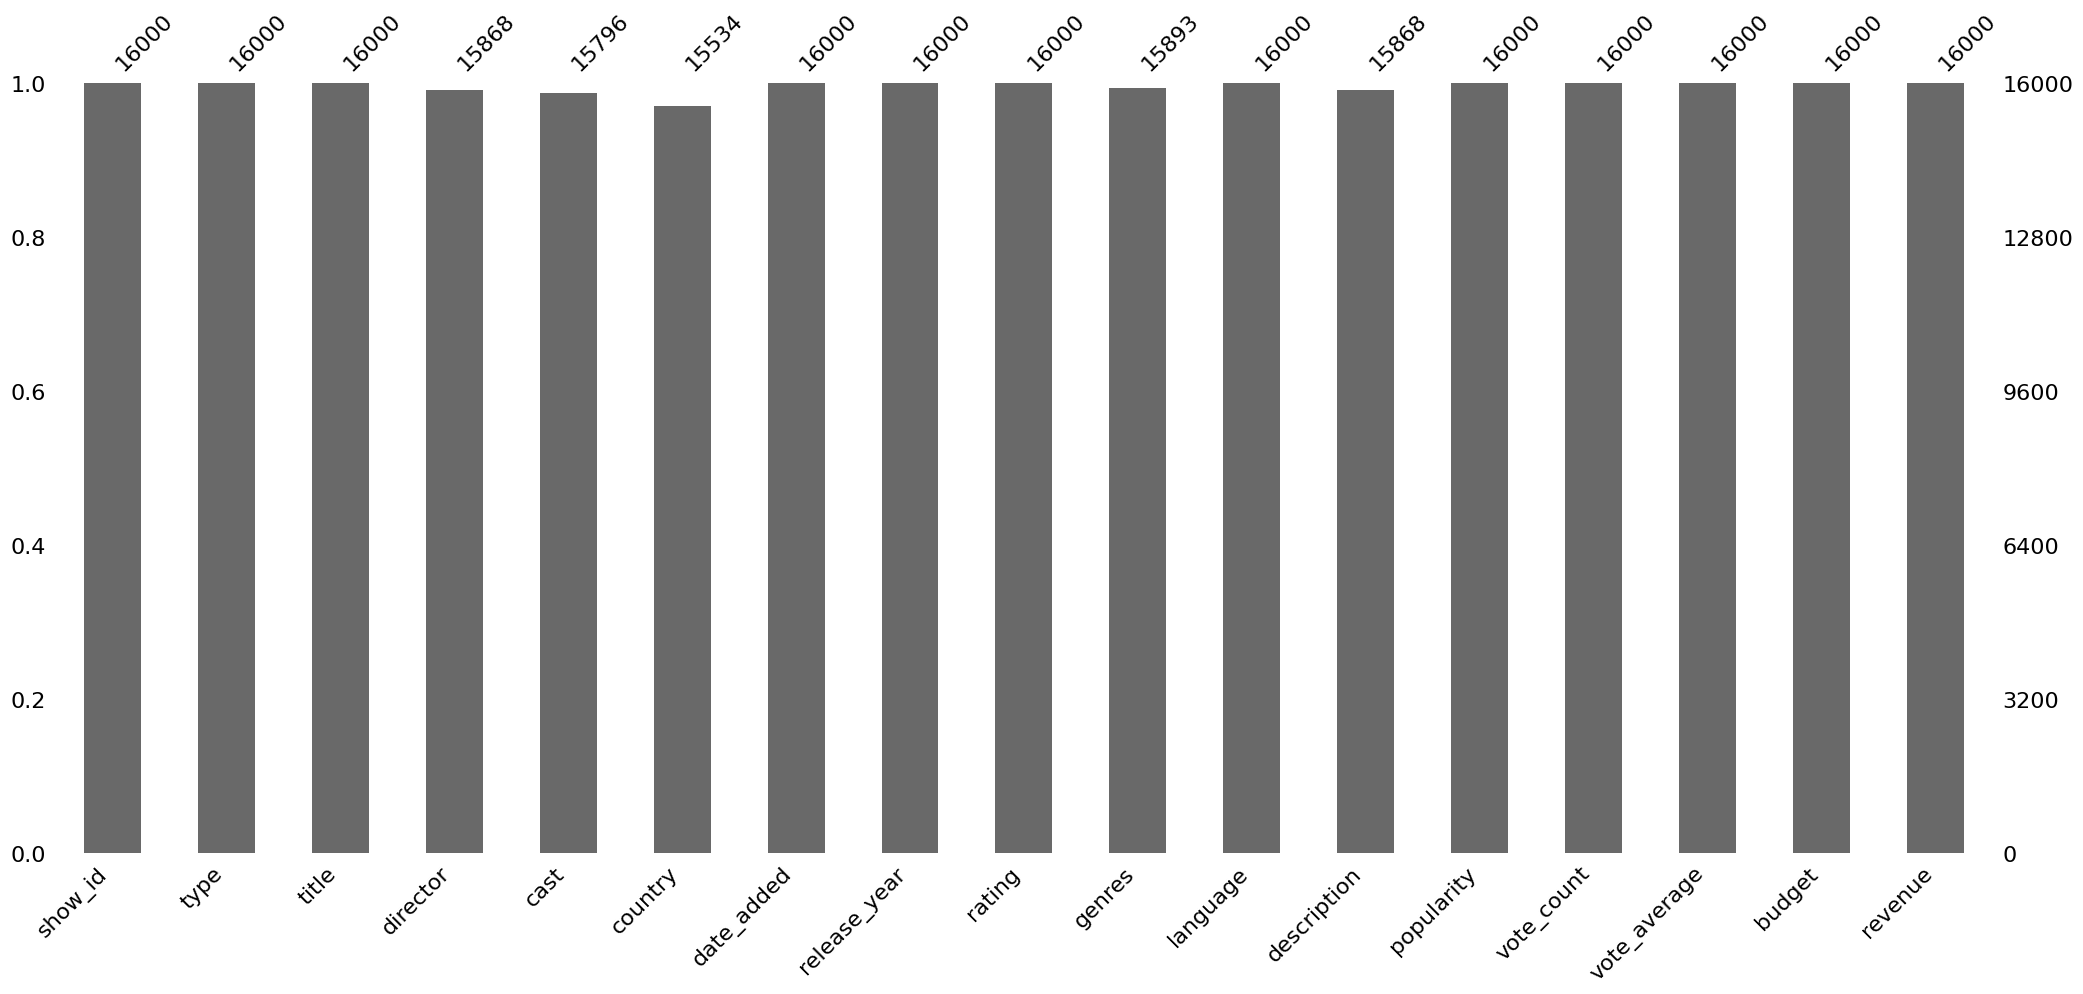

In [8]:
#finding patten in nan value
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(df)
plt.show()


In [9]:
#description fill nan with not available
df["description"].fillna("not available",inplace=True)

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,132
cast,204
country,466
date_added,0
release_year,0
rating,0
genres,107


In [11]:
#enable set option
pd.set_option("display.max_columns",None)

In [12]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.000,Music,es,not available,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.000,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.000,NaN,en,A Dunces Burden,4.921,0,0.000,0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   genres        15893 non-null  object 
 10  language      16000 non-null  object 
 11  description   16000 non-null  object 
 12  popularity    16000 non-null  float64
 13  vote_count    16000 non-null  int64  
 14  vote_average  16000 non-null  float64
 15  budget        16000 non-null  int64  
 16  revenue       16000 non-null  int64  
dtypes: float64(3), int64(5), object(9)
memory usage: 2.1+ MB


In [14]:
#fill nan value with not available
df.fillna("not available",inplace=True)

In [15]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,not available,Ha*ash,Chile,2025-02-24,2025,0.000,Music,es,not available,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",not available,2025-01-28,2025,1.000,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",not available,2025-03-10,2025,0.000,not available,en,A Dunces Burden,4.921,0,0.000,0,0


In [16]:
#genres unique
df["genres"].unique()

array(['Comedy, Adventure, Fantasy, Animation, Family',
       'Action, Science Fiction, Adventure', 'Adventure, Fantasy', ...,
       'Action, Thriller, Romance, Fantasy, Drama', 'Music, Animation',
       'Drama, Thriller, Mystery, Horror'], dtype=object)

In [17]:
#date_added column to date time formate
df["date_added"] = pd.to_datetime(df["date_added"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       16000 non-null  int64         
 1   type          16000 non-null  object        
 2   title         16000 non-null  object        
 3   director      16000 non-null  object        
 4   cast          16000 non-null  object        
 5   country       16000 non-null  object        
 6   date_added    16000 non-null  datetime64[ns]
 7   release_year  16000 non-null  int64         
 8   rating        16000 non-null  float64       
 9   genres        16000 non-null  object        
 10  language      16000 non-null  object        
 11  description   16000 non-null  object        
 12  popularity    16000 non-null  float64       
 13  vote_count    16000 non-null  int64         
 14  vote_average  16000 non-null  float64       
 15  budget        16000 non-null  int64 

In [19]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,not available,Ha*ash,Chile,2025-02-24,2025,0.000,Music,es,not available,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",not available,2025-01-28,2025,1.000,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",not available,2025-03-10,2025,0.000,not available,en,A Dunces Burden,4.921,0,0.000,0,0


In [20]:
#divide data numeric and category
num_col = [col for col in df.columns if df[col].dtype != "O"]
cat_col = [col for col in df.columns if col not in num_col]
#print
print("numeric column:",num_col)
print("category column:",cat_col)

numeric column: ['show_id', 'date_added', 'release_year', 'rating', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']
category column: ['type', 'title', 'director', 'cast', 'country', 'genres', 'language', 'description']


In [21]:
df[['budget','revenue','popularity','rating','vote_count']]

,budget,revenue,popularity,rating,vote_count
0,165000000,752600867,203.893,6.380,7449
1,160000000,839030630,156.242,8.369,37119
2,250000000,954305868,121.191,7.744,19327
3,260000000,592461732,111.762,7.600,11638
4,165000000,494879471,110.044,7.800,13259
...,...,...,...,...,...
15995,0,0,4.931,0.000,0
15996,0,0,4.930,0.000,0
15997,0,0,4.922,1.000,1
15998,0,0,4.921,0.000,0


In [22]:
#find how many 0 in buget and revenue
(df['budget'] == 0).sum()

np.int64(11153)

In [23]:
(df['revenue'] == 0).sum()

np.int64(10355)

In [24]:
#find buget corelation column only num column
df[num_col].corr()

,show_id,date_added,release_year,rating,popularity,vote_count,vote_average,budget,revenue
show_id,1.000000,0.926705,0.928273,-0.325255,0.096656,-0.185147,-0.325255,-0.141630,-0.114259
date_added,0.926705,1.000000,0.998004,-0.219923,0.132825,-0.104657,-0.219923,-0.035731,-0.042646
release_year,0.928273,0.998004,1.000000,-0.230341,0.131493,-0.106090,-0.230341,-0.036975,-0.043304
rating,-0.325255,-0.219923,-0.230341,1.000000,0.071178,0.173600,1.000000,0.096967,0.117231
popularity,0.096656,0.132825,0.131493,0.071178,1.000000,0.158254,0.071178,0.218221,0.216282
vote_count,-0.185147,-0.104657,-0.106090,0.173600,0.158254,1.000000,0.173600,0.666053,0.749207
vote_average,-0.325255,-0.219923,-0.230341,1.000000,0.071178,0.173600,1.000000,0.096967,0.117231
budget,-0.141630,-0.035731,-0.036975,0.096967,0.218221,0.666053,0.096967,1.000000,0.752193
revenue,-0.114259,-0.042646,-0.043304,0.117231,0.216282,0.749207,0.117231,0.752193,1.000000


### now we impute revenue column to update and replace o with predict column

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
#Prepare Data - Separate entries with revenue > 0 for model training
train_data = df[df['revenue'] > 0].copy()
test_data = df[df['revenue'] == 0].copy()

# Selecting key features for prediction
features = ['budget', 'popularity', 'vote_count', 'rating', 'release_year']

# Splitting data for training and testing
X = train_data[features]
y = train_data['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train a Random Forest Regressor
revenue_model = RandomForestRegressor(n_estimators=100, random_state=42)
revenue_model.fit(X_train, y_train)

#Evaluate the model
y_pred = revenue_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Model Evaluation - RMSE: {rmse}, R²: {r2}")

# Predict revenue for rows where it is currently 0
test_data['revenue'] = revenue_model.predict(test_data[features])
test_data['revenue_imputed'] = 1  # Add a flag for imputed rows

# Update the original dataframe
# Get indices where revenue was 0 and update with predicted values
zero_revenue_indices = df[df['revenue'] == 0].index
df.loc[zero_revenue_indices, 'revenue'] = test_data['revenue'].values

#  Verify updated rows (Optional)
print(f"Remaining zero-revenue entries: {df[df['revenue'] == 0].shape[0]}")
df.loc[zero_revenue_indices, ['title', 'budget', 'revenue']].head(10)

Model Evaluation - RMSE: 9124980056646276.0, R²: 0.6940902199339978
Remaining zero-revenue entries: 0


,title,budget,revenue
14,A Serbian Film,0,87128774.24
17,Three Steps Above Heaven,0,37667530.84
44,Titanic II,0,17047977.60
49,Tinker Bell and the Great Fairy Rescue,0,15583980.21
52,Scared Shrekless,0,18006008.36
55,Azureus Rising,0,47679304.14
59,Death Race 2,7000000,32783756.01
71,Splice,26000000,87351626.77
74,Tabu,0,12186107.10
77,16 Wishes,0,15304414.22


In [27]:
#we do same as buget column
#Prepare Data - Separate entries with buget > 0 for model training
train_data = df[df['budget'] > 0].copy()
test_data = df[df['budget'] == 0].copy()

# Selecting key features for prediction
features = ['revenue', 'popularity', 'vote_count', 'rating', 'release_year']

# Splitting data for training and testing
X = train_data[features]
y = train_data['budget']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train a Random Forest Regressor
budget_model = RandomForestRegressor(n_estimators=100, random_state=42)
budget_model.fit(X_train, y_train)

# Evaluate the model
y_pred = budget_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Model Evaluation - RMSE: {rmse}, R²: {r2}")

# Predict budget for rows where it is currently 0
test_data['budget'] = budget_model.predict(test_data[features])
test_data['budget_imputed'] = 1  # Add a flag for imputed rows


# Get indices where budget was 0 and update with predicted values
zero_budget_indices = df[df['budget'] == 0].index
df.loc[zero_budget_indices, 'budget'] = test_data['budget'].values

# Verify updated rows (Optional)
print(f"Remaining zero-budget entries: {df[df['budget'] == 0].shape[0]}")
df.loc[zero_budget_indices, ['title', 'budget', 'revenue']].head(10)


Model Evaluation - RMSE: 685589404668684.2, R²: 0.6817272184399592
Remaining zero-budget entries: 0


,title,budget,revenue
9,Room in Rome,22090368.41,844281.00
14,A Serbian Film,39239000.00,87128774.24
17,Three Steps Above Heaven,16198000.00,37667530.84
28,El Infierno,12134136.43,6703873.00
32,Elite Squad: The Enemy Within,18659899.73,63027681.00
40,Halo Legends,8323410.34,11000000.00
44,Titanic II,35314257.63,17047977.60
49,Tinker Bell and the Great Fairy Rescue,12006769.15,15583980.21
52,Scared Shrekless,25397784.29,18006008.36
55,Azureus Rising,29568097.50,47679304.14


In [28]:
df[['budget','revenue','popularity','rating','vote_count']].describe()

,budget,revenue,popularity,rating,vote_count
count,1.600000e+04,1.600000e+04,16000.000000,16000.000000,16000.000000
mean,1.456166e+07,3.394427e+07,20.384728,5.956368,718.656125
std,2.832993e+07,1.114046e+08,68.610033,1.754741,2080.198316
min,1.000000e+00,2.000000e+00,3.860000,0.000000,0.000000
25%,4.154621e+06,3.300000e+06,7.840750,5.600000,53.000000
50%,6.961703e+06,8.847472e+06,10.913500,6.300000,138.000000
75%,1.237457e+07,2.031316e+07,17.336500,6.923000,422.000000
max,4.600000e+08,2.799439e+09,3876.006000,10.000000,37119.000000


In [29]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,1.650000e+08,7.526009e+08
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,1.600000e+08,8.390306e+08
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,2.500000e+08,9.543059e+08
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,2.600000e+08,5.924617e+08
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,1.650000e+08,4.948795e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,not available,Ha*ash,Chile,2025-02-24,2025,0.000,Music,es,not available,4.931,0,0.000,1.657314e+06,1.141490e+07
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,1.657314e+06,1.141490e+07
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",not available,2025-01-28,2025,1.000,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,2.118583e+06,9.849007e+06
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",not available,2025-03-10,2025,0.000,not available,en,A Dunces Burden,4.921,0,0.000,1.727314e+06,1.141490e+07


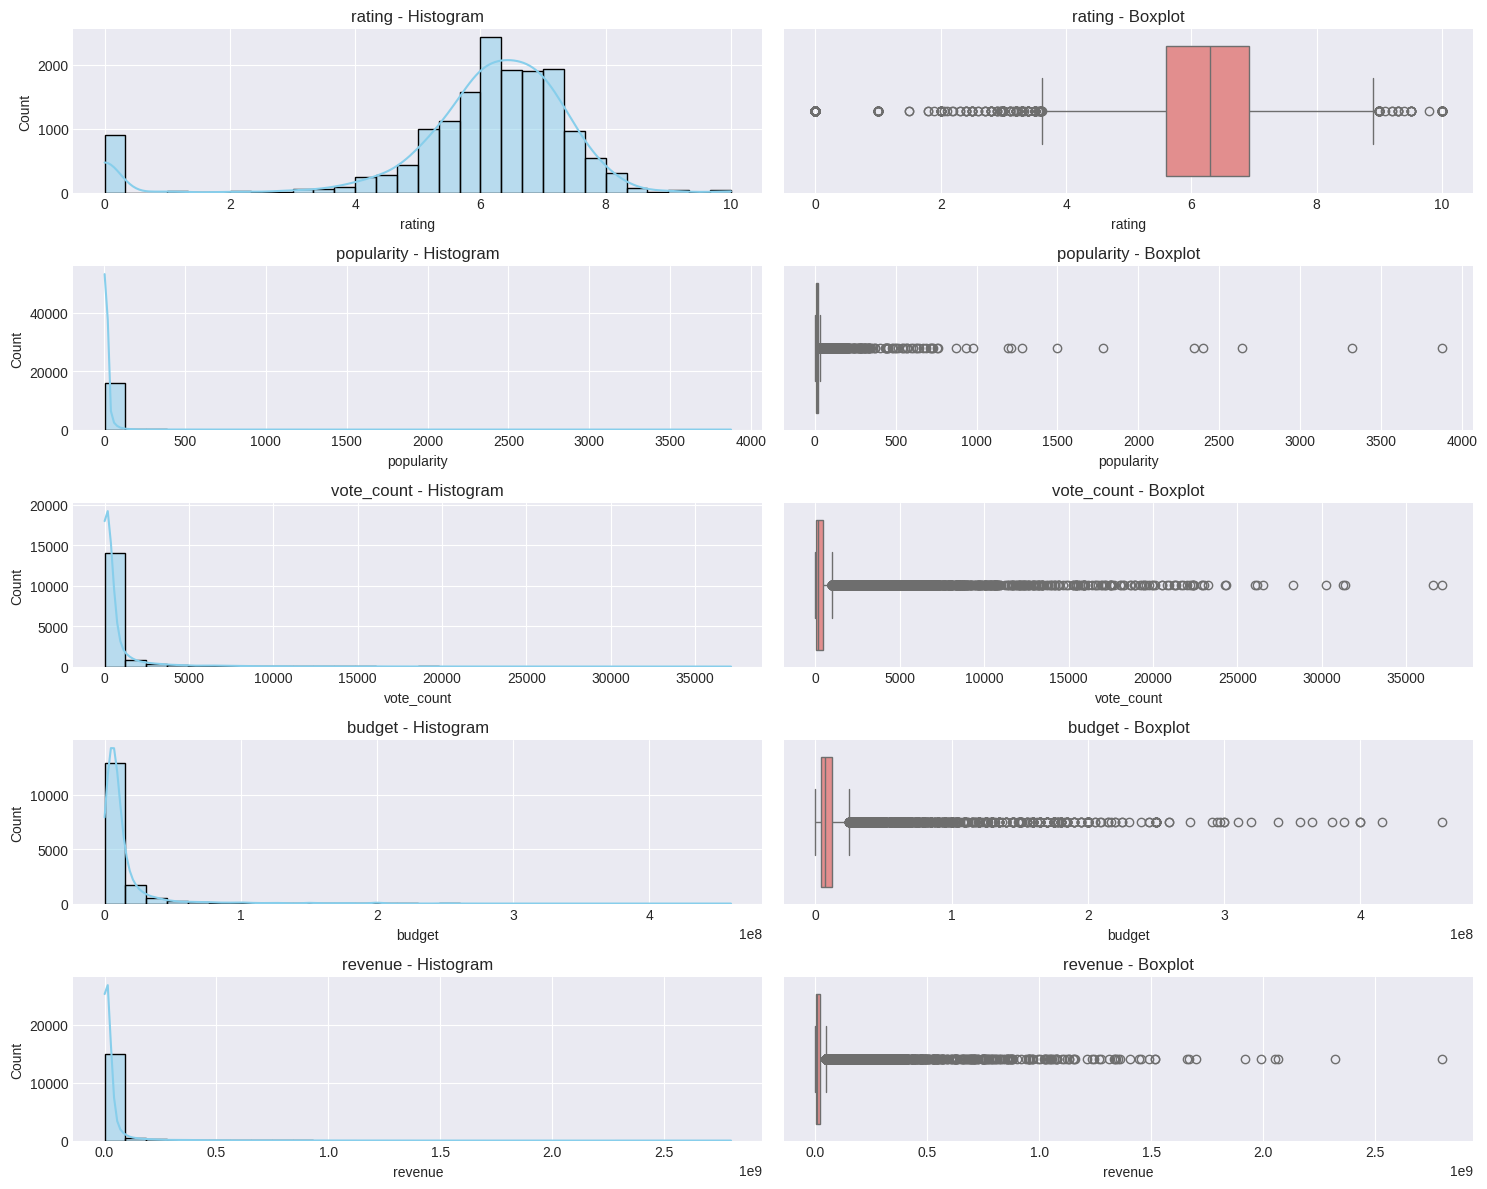

In [30]:
# Set plot style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# List of numerical columns for visualization
num_cols = ['rating', 'popularity', 'vote_count', 'budget', 'revenue']

# Visualizing distribution and boxplots for each column
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 2, 2 * i - 1)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'{col} - Histogram')

    plt.subplot(5, 2, 2 * i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()


# Observations from the Visuals:

- Rating:Distribution appears fairly normal with few minor outliers on both ends.

-Popularity:Highly skewed with extreme outliers; some values are significantly higher than the rest.

- Vote Count:Similar to popularity, this has a few extreme outliers indicating heavily rated content.

- Budget and Revenue:Both exhibit extreme outliers, common in media/entertainment data where blockbuster hits distort averages.

- show_id and release_year has no outliers

In [31]:
# outlier detect function
def detect_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

# Checking remaining outliers
outlier_counts = {col: detect_outliers_iqr(col) for col in ['rating', 'popularity', 'vote_count', 'budget', 'revenue']}

outlier_counts

{'rating': 1172,
 'popularity': 1705,
 'vote_count': 2287,
 'budget': 1851,
 'revenue': 1989}

In [32]:
# outlier treatment
# Function to cap outliers using the IQR method
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # 25th percentile (Q1)
    Q3 = df[column].quantile(0.75)  # 75th percentile (Q3)
    IQR = Q3 - Q1  # Interquartile range

    # Define upper and lower bounds for capping
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values that exceed the bounds
    df[column] = df[column].apply(lambda x: min(max(x, lower_bound), upper_bound))
    return lower_bound, upper_bound

# Apply the capping function to selected columns and store the bounds
columns_to_cap = ['budget', 'revenue', 'popularity', 'vote_count','rating']
bounds = {col: cap_outliers(df, col) for col in columns_to_cap}

# Displaying the new statistics after capping
summary_after_capping = df[columns_to_cap].describe()

bounds, summary_after_capping


({'budget': (np.float64(-8175299.288749998), np.float64(24704488.381249998)),
  'revenue': (np.float64(-22219733.685), np.float64(45832889.474999994)),
  'popularity': (np.float64(-6.402875000000002),
   np.float64(31.580125000000002)),
  'vote_count': (np.float64(-500.5), np.float64(975.5)),
  'rating': (np.float64(3.615499999999999), np.float64(8.9075))},
              budget       revenue    popularity    vote_count        rating
 count  1.600000e+04  1.600000e+04  16000.000000  16000.000000  16000.000000
 mean   9.403430e+06  1.466596e+07     13.920054    295.333719      6.167681
 std    7.272629e+06  1.497485e+07      8.181239    336.107980      1.120725
 min    1.000000e+00  2.000000e+00      3.860000      0.000000      3.615500
 25%    4.154621e+06  3.300000e+06      7.840750     53.000000      5.600000
 50%    6.961703e+06  8.847472e+06     10.913500    138.000000      6.300000
 75%    1.237457e+07  2.031316e+07     17.336500    422.000000      6.923000
 max    2.470449e+07  4.

In [33]:
# outlier detect function
def detect_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

# Checking remaining outliers
outlier_counts = {col: detect_outliers_iqr(col) for col in ['rating', 'popularity', 'vote_count', 'budget', 'revenue']}

outlier_counts

{'rating': 0, 'popularity': 0, 'vote_count': 0, 'budget': 0, 'revenue': 0}

#now movie data clean , preproceesiong,outlier treatment was done we move to tv show data
## load ,tranform, clean , outlier treatment



In [34]:
#load data /content/netflix_tv_shows_detailed_up_to_2025.csv
df2 = pd.read_csv("/content/netflix_tv_shows_detailed_up_to_2025.csv")
df2.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


In [35]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB


In [36]:
#describe with all
df2.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
count,16000.000000,16000,16000,5035,14843,14203,16000,16000.000000,16000.000000,16000,15026,16000,12794,16000.000000,16000.000000,16000.000000
unique,NaN,1,15668,3808,14628,564,4899,NaN,NaN,1,1218,71,12782,NaN,NaN,NaN
top,NaN,TV Show,The Voice Kids,Don Michael Perez,"Qing Zu, Deng Yuting, Ying Liang, Hongyun Liu,...",United States of America,2025-03-01,NaN,NaN,1 Seasons,Drama,en,Seventeen-year-old Mugi Awaya and Hanabi Yasur...,NaN,NaN,NaN
freq,NaN,16000,6,16,10,2339,112,NaN,NaN,16000,2744,4437,2,NaN,NaN,NaN
mean,126567.673375,NaN,NaN,NaN,NaN,NaN,NaN,2017.500000,5.417107,NaN,NaN,NaN,NaN,64.850984,107.014313,5.417107
std,75640.760545,NaN,NaN,NaN,NaN,NaN,NaN,4.609916,3.266492,NaN,NaN,NaN,NaN,139.387289,607.461581,3.266492
min,767.000000,NaN,NaN,NaN,NaN,NaN,NaN,2010.000000,0.000000,NaN,NaN,NaN,NaN,2.323000,0.000000,0.000000
25%,67867.750000,NaN,NaN,NaN,NaN,NaN,NaN,2013.750000,2.700000,NaN,NaN,NaN,NaN,24.874750,1.000000,2.700000
50%,94380.500000,NaN,NaN,NaN,NaN,NaN,NaN,2017.500000,6.800000,NaN,NaN,NaN,NaN,36.187500,4.000000,6.800000
75%,206920.750000,NaN,NaN,NaN,NaN,NaN,NaN,2021.250000,7.800000,NaN,NaN,NaN,NaN,62.187500,30.000000,7.800000


In [37]:
#duration unique
df2["duration"].unique()

array(['1 Seasons'], dtype=object)

In [38]:
#change column name "duration" in to "duration/seasons"
df2.rename(columns={"duration":"duration/seasons"},inplace=True)

In [39]:
# Handling Missing Values
df2['director'].fillna("Not Available", inplace=True)
df2['cast'].fillna("Not Available", inplace=True)
df2['country'].fillna("Unknown", inplace=True)
df2['description'].fillna("No Information", inplace=True)
df2['genres'].fillna("No Information", inplace=True)

# Convert 'date_added' to datetime format
df2['date_added'] = pd.to_datetime(df2['date_added'])


# Extract numeric value from 'duration' column
df2['duration/seasons'] = df2['duration/seasons'].str.extract('(\d+)').astype(float)

#  Confirm changes
missing_data_after_cleaning = df2.isnull().sum()

missing_data_after_cleaning


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration/seasons,0


In [40]:
df2

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration/seasons,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1.0,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,Not Available,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1.0,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,Not Available,Not Available,Greece,2010-10-03,2010,5.600,1.0,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,Not Available,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1.0,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,Not Available,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1.0,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,284892,TV Show,Sammelanam,Not Available,Not Available,Unknown,2025-02-20,2025,0.000,1.0,"Comedy, Drama",te,Sammelanam is a gripping Telugu web series tha...,3.236,0,0.000
15996,277665,TV Show,Anne Shirley,Not Available,"Honoka Inoue, Yasunori Matsumoto, Aya Nakamura...",Japan,2025-04-05,2025,0.000,1.0,"Animation, Drama, Family",ja,It's depict Anne's growth from a girl to a wom...,3.558,0,0.000
15997,284972,TV Show,Le onde del passato,Giulio Manfredonia,"Anna Valle, Giorgio Marchesi, Irene Ferri, Fau...",Unknown,2025-02-19,2025,10.000,1.0,Drama,it,No Information,2.913,1,10.000
15998,284613,TV Show,AI히치하이커,Not Available,Not Available,Unknown,2025-02-16,2025,0.000,1.0,No Information,ko,No Information,2.787,0,0.000


In [41]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           16000 non-null  int64         
 1   type              16000 non-null  object        
 2   title             16000 non-null  object        
 3   director          16000 non-null  object        
 4   cast              16000 non-null  object        
 5   country           16000 non-null  object        
 6   date_added        16000 non-null  datetime64[ns]
 7   release_year      16000 non-null  int64         
 8   rating            16000 non-null  float64       
 9   duration/seasons  16000 non-null  float64       
 10  genres            16000 non-null  object        
 11  language          16000 non-null  object        
 12  description       16000 non-null  object        
 13  popularity        16000 non-null  float64       
 14  vote_count        1600

In [42]:
num_col2 = [col for col in df2.columns if df2[col].dtype != "O"]
cat_col2 = [col for col in df2.columns if col not in num_col2]
print("numeric column:",num_col2)
print("category column:",cat_col2)

numeric column: ['show_id', 'date_added', 'release_year', 'rating', 'duration/seasons', 'popularity', 'vote_count', 'vote_average']
category column: ['type', 'title', 'director', 'cast', 'country', 'genres', 'language', 'description']


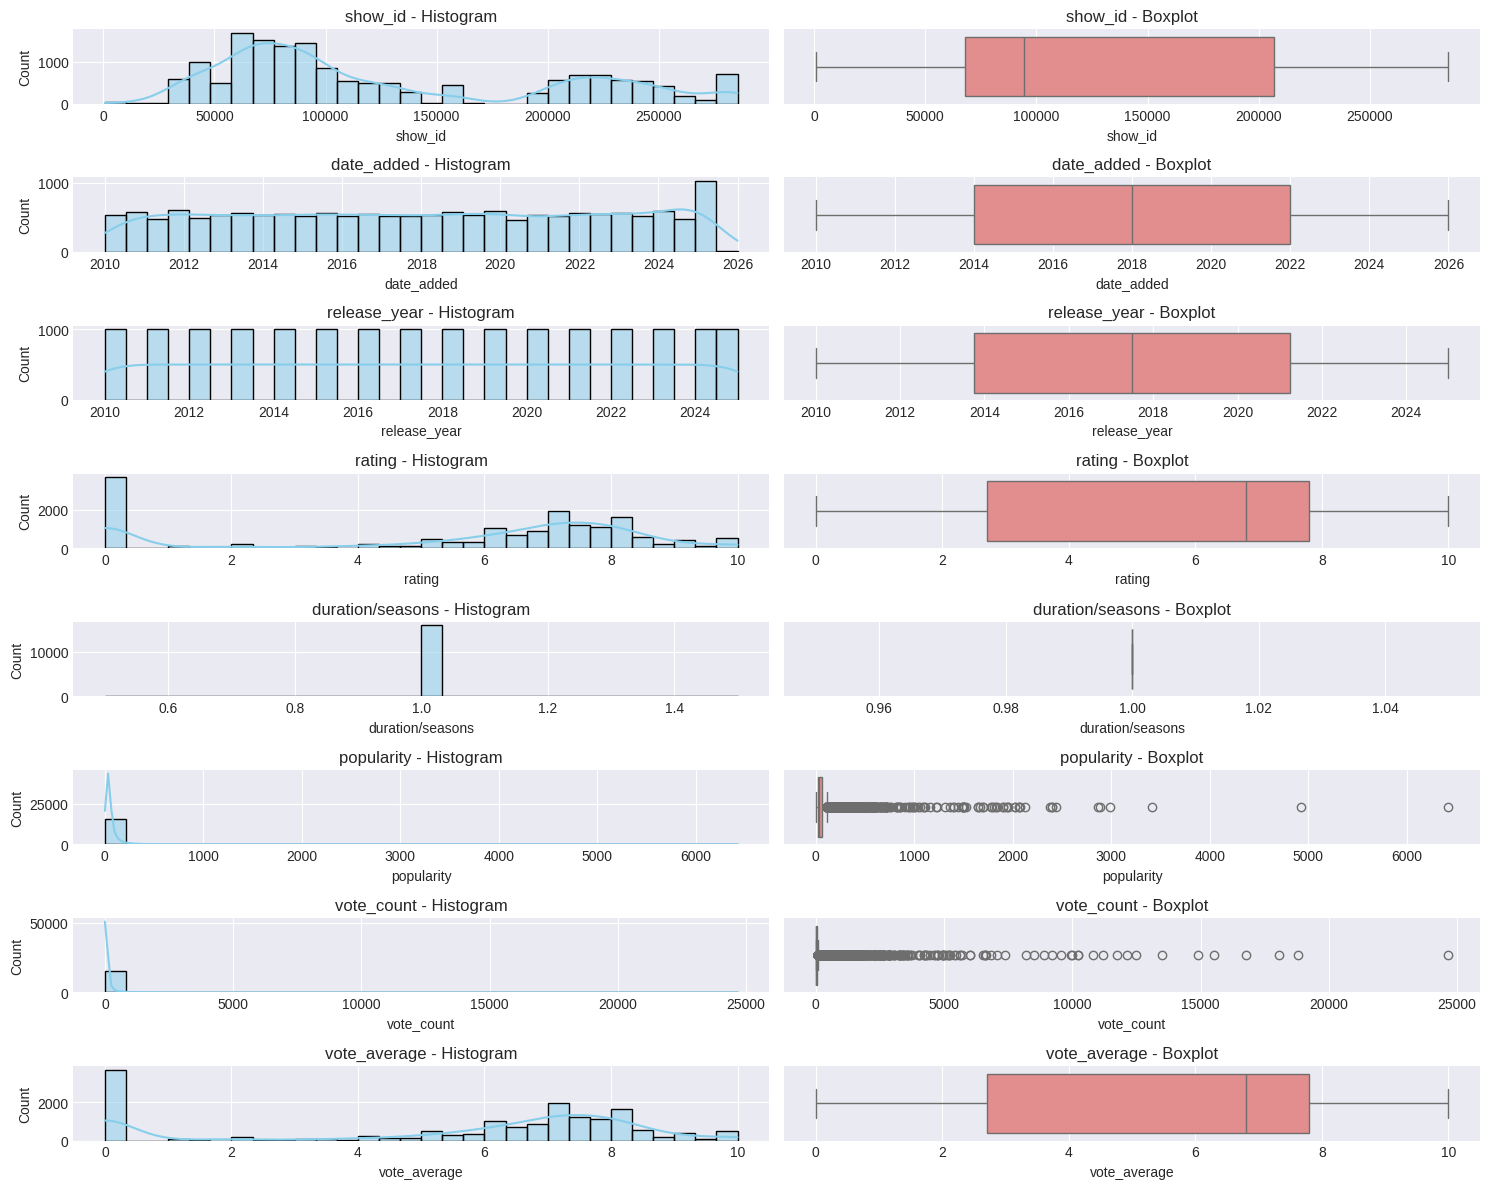

In [43]:
#visualze boxplot and histograme on num column
plt.figure(figsize=(15, 12))

for i in range(len(num_col2)):
    plt.subplot(len(num_col2), 2, 2 * i + 1)
    sns.histplot(df2[num_col2[i]], bins=30, kde=True, color='skyblue')
    plt.title(f'{num_col2[i]} - Histogram')

    plt.subplot(len(num_col2), 2, 2 * i + 2)
    sns.boxplot(x=df2[num_col2[i]], color='lightcoral')
    plt.title(f'{num_col2[i]} - Boxplot')

    plt.tight_layout()
plt.show()

In [44]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(column):
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df2[(df2[column] < lower_bound) | (df2[column] > upper_bound)]
    return len(outliers)

# Checking remaining outliers
outlier_counts = {col: detect_outliers_iqr(col) for col in ['show_id', 'date_added', 'release_year', 'rating', 'duration/seasons', 'popularity', 'vote_count', 'vote_average']}

outlier_counts

{'show_id': 0,
 'date_added': 0,
 'release_year': 0,
 'rating': 0,
 'duration/seasons': 0,
 'popularity': 1609,
 'vote_count': 2661,
 'vote_average': 0}

# since popularity and vote cout has outlier then we use only on them

In [45]:
#outlier treatment for popularity and vote count
columns_to_cap = ['popularity', 'vote_count']
bounds = {col: cap_outliers(df2, col) for col in columns_to_cap}

In [46]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(column):
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df2[(df2[column] < lower_bound) | (df2[column] > upper_bound)]
    return len(outliers)

# Checking remaining outliers
outlier_counts = {col: detect_outliers_iqr(col) for col in ['show_id', 'date_added', 'release_year', 'rating', 'duration/seasons', 'popularity', 'vote_count', 'vote_average']}

outlier_counts

{'show_id': 0,
 'date_added': 0,
 'release_year': 0,
 'rating': 0,
 'duration/seasons': 0,
 'popularity': 0,
 'vote_count': 0,
 'vote_average': 0}

### done both dataset clean,preprocessing and outlier tretment


#  ✅ Exploratory Data Analysis (EDA) with insights visualization also feature engineering


###  EDA Plan:
- Overview & Correlations: Check distributions, correlations, and key relationships.
- Top Genres, Countries, and Release Trends.
- Rating & Popularity Analysis (TV and Movies).
- Top 10 Highest Rated and Most Popular Movies & TV Shows
- Revenue, Budget, and Success Trends (Movies dataset).

In [47]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,31.580125,975.5,6.380,2.470449e+07,4.583289e+07
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",31.580125,975.5,8.369,2.470449e+07,4.583289e+07
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",31.580125,975.5,7.744,2.470449e+07,4.583289e+07
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",31.580125,975.5,7.600,2.470449e+07,4.583289e+07
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,31.580125,975.5,7.800,2.470449e+07,4.583289e+07


In [48]:
df.describe()

,show_id,date_added,release_year,rating,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2018-01-04 21:54:37.799999744,2017.500000,6.167681,13.920054,295.333719,5.956368,9.403430e+06,1.466596e+07
min,1.890000e+02,2010-01-01 00:00:00,2010.000000,3.615500,3.860000,0.000000,0.000000,1.000000e+00,2.000000e+00
25%,2.257258e+05,2013-12-31 18:00:00,2013.750000,5.600000,7.840750,53.000000,5.600000,4.154621e+06,3.300000e+06
50%,4.468170e+05,2017-12-31 12:00:00,2017.500000,6.300000,10.913500,138.000000,6.300000,6.961703e+06,8.847472e+06
75%,7.739808e+05,2021-12-31 06:00:00,2021.250000,6.923000,17.336500,422.000000,6.923000,1.237457e+07,2.031316e+07
max,1.440471e+06,2025-12-25 00:00:00,2025.000000,8.907500,31.580125,975.500000,10.000000,2.470449e+07,4.583289e+07
std,3.794427e+05,NaN,4.609916,1.120725,8.181239,336.107980,1.754741,7.272629e+06,1.497485e+07


In [49]:
df2.describe()

,show_id,date_added,release_year,rating,duration/seasons,popularity,vote_count,vote_average
count,16000.000000,16000,16000.000000,16000.000000,16000.0,16000.000000,16000.000000,16000.000000
mean,126567.673375,2017-12-14 02:26:25.800000256,2017.500000,5.417107,1.0,48.255903,19.768469,5.417107
min,767.000000,2010-01-01 00:00:00,2010.000000,0.000000,1.0,2.323000,0.000000,0.000000
25%,67867.750000,2013-12-31 18:00:00,2013.750000,2.700000,1.0,24.874750,1.000000,2.700000
50%,94380.500000,2017-12-31 12:00:00,2017.500000,6.800000,1.0,36.187500,4.000000,6.800000
75%,206920.750000,2021-12-31 06:00:00,2021.250000,7.800000,1.0,62.187500,30.000000,7.800000
max,285345.000000,2025-12-31 00:00:00,2025.000000,10.000000,1.0,118.156625,73.500000,10.000000
std,75640.760545,NaN,4.609916,3.266492,0.0,32.248664,27.584058,3.266492


## Overview & Correlations: Check distributions, correlations, and key relationships.

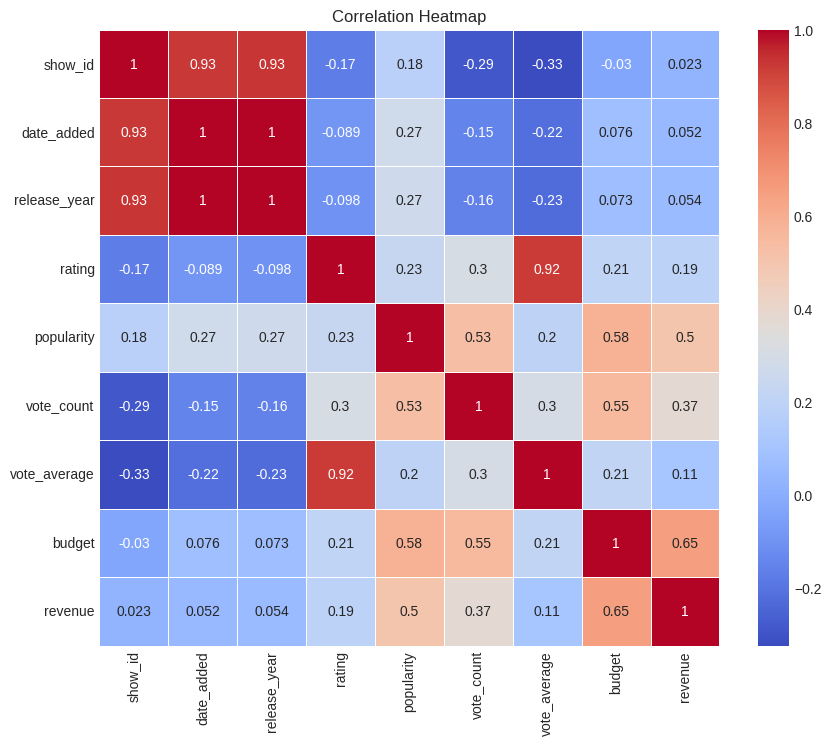

In [50]:
#movie dataset check corelation ship on numcol
df[num_col].corr()

#visualize
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Strong Correlations:
budget and revenue:
There is a strong positive correlation (around 0.65) between budget and revenue. This suggests that movies with higher budgets tend to generate higher revenue, though other factors also contribute.

vote_count and popularity:
Moderate to strong correlation (~0.53), indicating that popular shows tend to gather more votes from viewers.

vote_average and rating:
Strong correlation (~0.92), suggesting that these two variables are closely related. This makes sense because they both reflect viewer feedback.

Weak or No Correlations:
release_year and revenue:
Weak correlation (~0.05), suggesting that the release year doesn’t significantly impact the revenue.

popularity and vote_average:
A weak correlation (~0.2), implying that popular shows may not always have high average ratings.

date_added and budget:
Low correlation (~0.07), indicating that the date when a movie or show was added to Netflix isn’t tied to its budget.

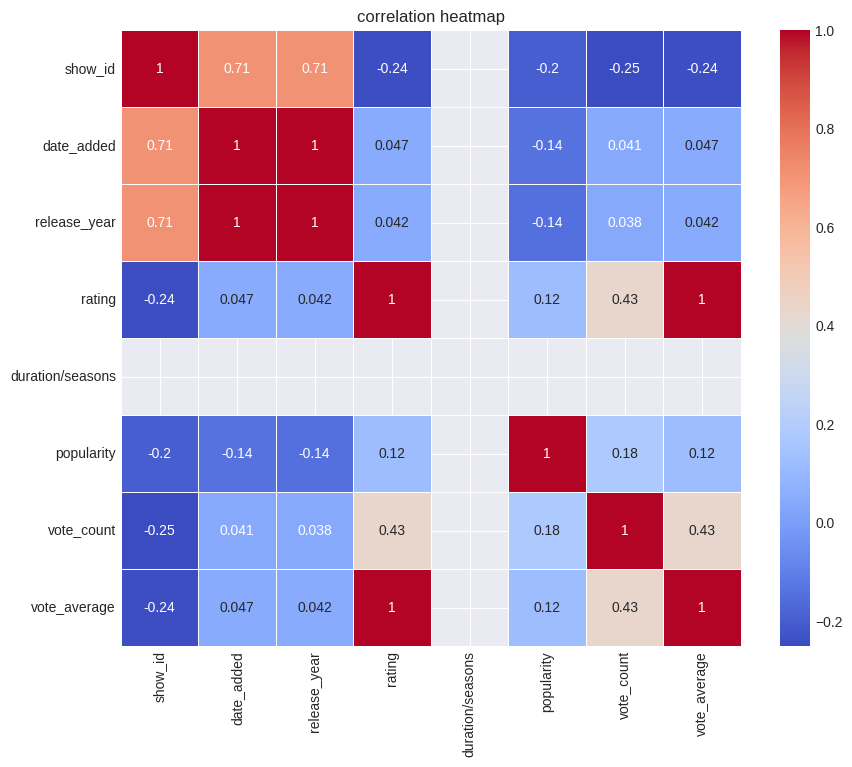

In [51]:
#check co-relation on tv show dataset
df2[num_col2].corr()

#visualize
plt.figure(figsize=(10,8))
sns.heatmap(df2[num_col2].corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

Moderate Positive Correlations:
vote_count and vote_average:
Moderate correlation (~0.43), indicating that TV shows with more votes tend to have higher average ratings.

popularity and vote_count:
Slight positive correlation (~0.18), suggesting that shows with more votes tend to be more popular, but other factors might also influence popularity.

rating and vote_average:
Strong correlation (~1). This is expected since both reflect viewer opinions, and they are likely measuring similar feedback.

release_year and popularity:
Weak correlation (~-0.14), suggesting that the popularity of a TV show isn’t directly linked to its release year.

duration/seasons and popularity:
Weak correlation, implying that the number of seasons doesn’t strongly influence a show’s popularity.

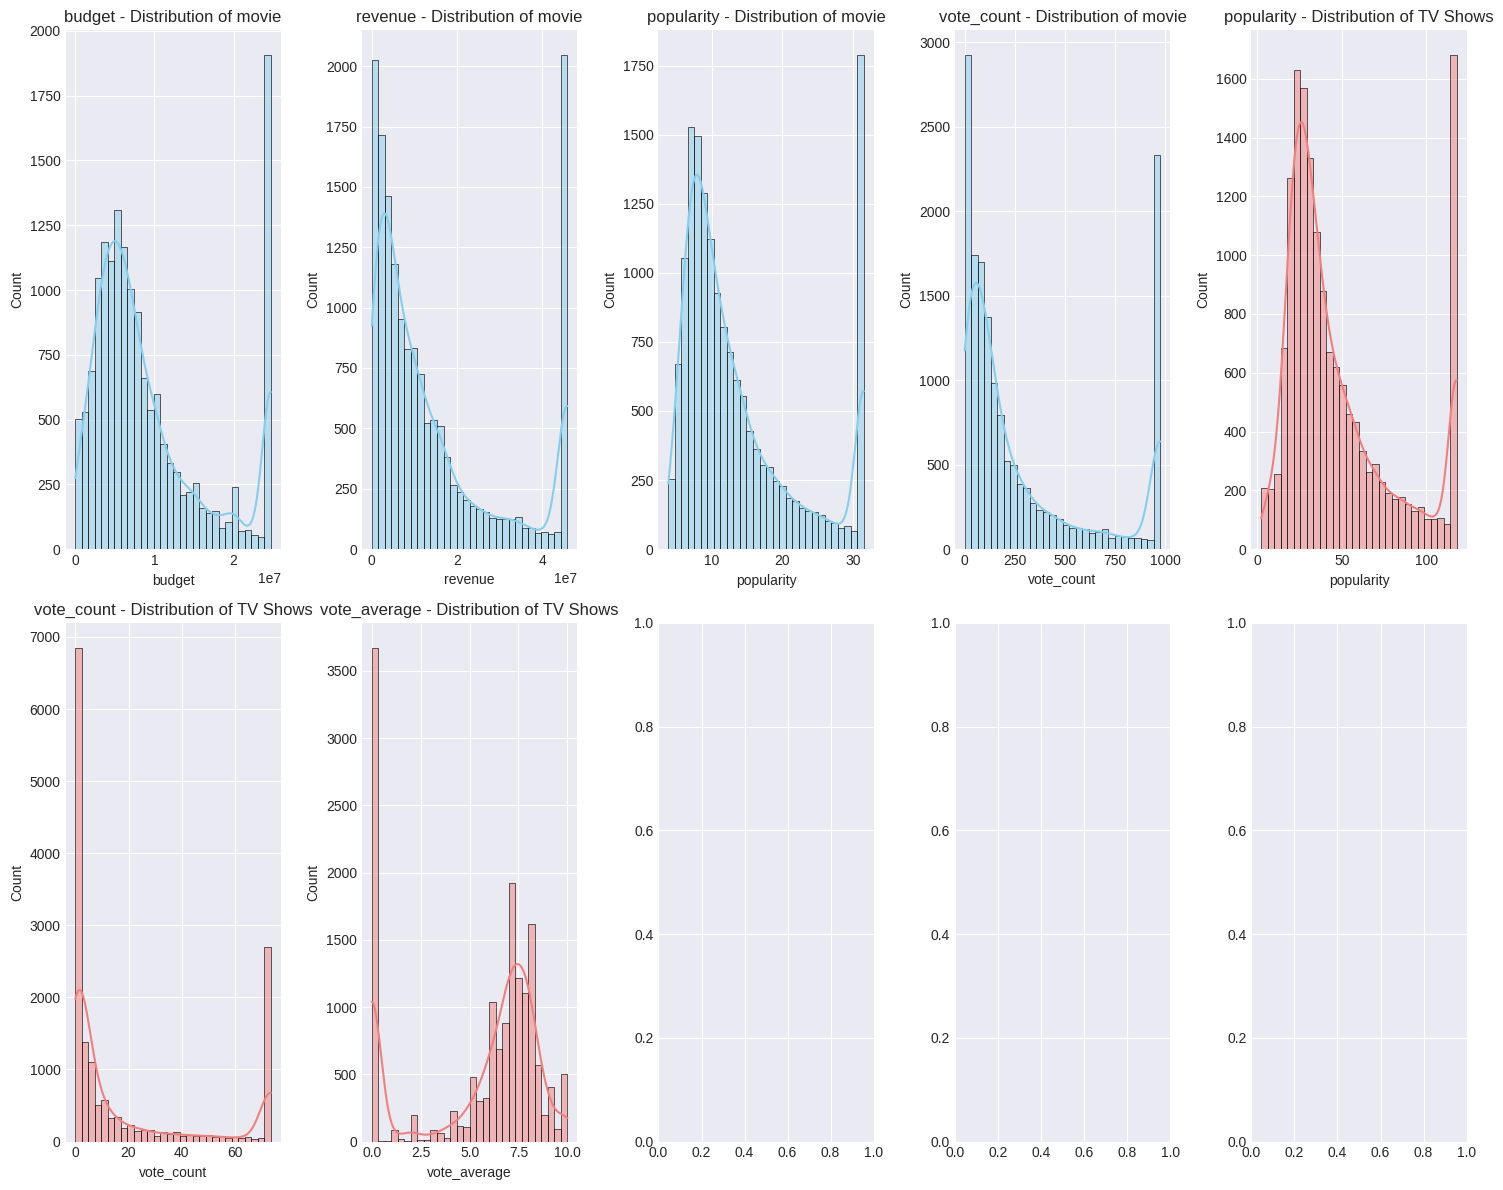

In [52]:
# Plotting Distribution of Key Columns - Movies and TV Shows Dataset

# Define relevant columns for distribution analysis
key_columns_movies = df[['budget','revenue','popularity','vote_count']]
key_columns_tv_shows = df2[['popularity','vote_count','vote_average']]


# Updated figure size to accommodate more subplots
fig, axes = plt.subplots(2, len(key_columns_movies.columns) + len(key_columns_tv_shows.columns) // 2, figsize=(15, 12))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Current subplot index
subplot_index = 0

# Movies Dataset - Distributions of Key Columns
for i, col in enumerate(key_columns_movies.columns):
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', ax=axes[subplot_index])
    axes[subplot_index].set_title(f'{col} - Distribution of movie')
    subplot_index += 1

# TV Shows Dataset - Distributions of Key Columns
for i, col in enumerate(key_columns_tv_shows.columns):
    sns.histplot(df2[col], bins=30, kde=True, color='lightcoral', ax=axes[subplot_index])
    axes[subplot_index].set_title(f'{col} - Distribution of TV Shows')
    subplot_index += 1

plt.tight_layout()
plt.show()

For Movies:
Budget Distribution (Top Left):The distribution is right-skewed, with most movies having a lower budget.
Only a few movies have exceptionally high budgets, indicating the presence of budget outliers.
This skewed nature suggests that low-to-medium-budget movies dominate the dataset.


Revenue Distribution (Top Middle):Like the budget, revenue distribution is also heavily right-skewed.
A significant number of movies earn relatively low revenue, while a small number of blockbuster movies generate massive revenue.
This suggests that high revenue is rare and concentrated in select big-budget or highly popular films.


Popularity Distribution (Top Right):Most movies have low popularity scores, with only a few outliers at the higher end.This could indicate that while many movies are available, only a small fraction gains significant popularity among users.


Vote Count Distribution (Bottom Left of First Row):This distribution shows that most movies receive a low number of votes, while a few receive a very high vote count, indicating blockbuster or cult-hit movies.


For TV Shows:
Popularity Distribution (Top Right):Similar to movies, TV shows also show a right-skewed distribution.
Only a small number of TV shows achieve high popularity, while most stay under the radar.



Vote Count Distribution (Bottom Left):Most TV shows have very few votes, which might indicate niche audiences or newer content with limited viewership.
A small number of highly voted TV shows dominate, possibly reflecting hits or long-running series.


Vote Average Distribution (Bottom Right):This distribution shows a concentration around higher ratings, possibly indicating a user tendency to rate TV shows favorably.
TV shows may generally enjoy higher average ratings than movies, possibly due to loyal viewers.


## Top Genres, Countries, and Release Trends.

<Figure size 2000x1200 with 0 Axes>

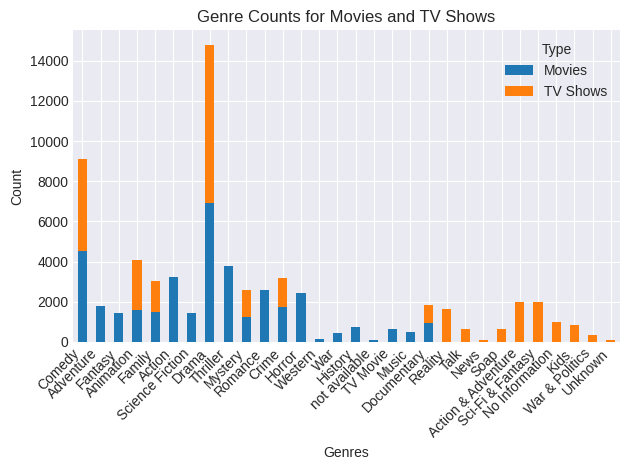

<Figure size 2000x1200 with 0 Axes>

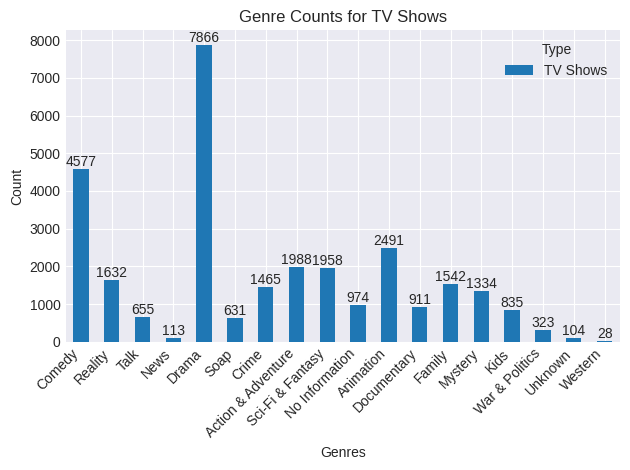

<Figure size 2000x1200 with 0 Axes>

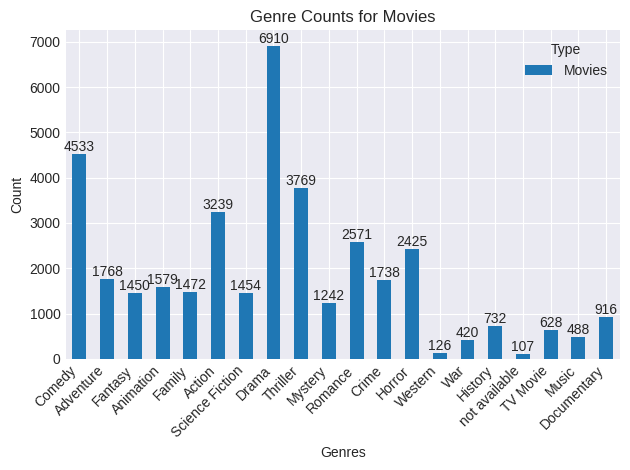

In [53]:
# Genre Analysis: Identifying most common and underrepresented genres in both movies and TV shows

# Function to split and count genres from the genre column (handling multiple genres)
def count_genres(df, column):
    genre_counts = {}
    for genres in df[column]:
        if isinstance(genres, str):
            for genre in genres.split(','):
                genre_counts[genre.strip()] = genre_counts.get(genre.strip(), 0) + 1
    return genre_counts

# Counting genres in movies and TV shows datasets
genre_counts_movies = count_genres(df, 'genres')
genre_counts_tv_shows = count_genres(df2, 'genres')

# Creating a DataFrame for better visualization
genre_df = pd.DataFrame({'Movies': genre_counts_movies, 'TV Shows': genre_counts_tv_shows}).fillna(0)
genre_df2 = pd.DataFrame({'TV Shows': genre_counts_tv_shows}).fillna(0)
genre_df1 = pd.DataFrame({'Movies': genre_counts_movies}).fillna(0)

#  Plotting the genre counts for movies and TV shows
plt.figure(figsize=(20, 12))
genre_df.plot(kind='bar', stacked=True)
plt.title('Genre Counts for Movies and TV Shows')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

# 'Genre Counts for TV Shows'
plt.figure(figsize=(20, 12))
genre_df2.plot(kind='bar')
plt.title('Genre Counts for TV Shows')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.bar_label(plt.gca().containers[0], label_type='edge')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

# 'Genre Counts for Movies'
plt.figure(figsize=(20, 12))
genre_df1.plot(kind='bar')
plt.title('Genre Counts for Movies')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.bar_label(plt.gca().containers[0], label_type='edge')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

Most Common Genres:

TV Shows:
Drama is the most common genre with over 7866 entries, followed by Comedy (~4577).
Other frequent genres include Reality, Action & Adventure, Documentary, and Crime.
Genres like Politics, Western, and Unknown are significantly underrepresented.

Movies:
Drama also dominates the movie dataset, followed by Comedy, Thriller, and Action.
Genres such as Western, War, Music, and TV Movie are the least common, suggesting niche interest or limited availability.

Underrepresented Genres:TV Show genres like Politics, Western, and Unknown have very few shows.
Movie genres such as Western, War, History, and TV Movie show limited counts, indicating possible content gaps in these areas.


Popular Genres in Both Categories:Drama and Comedy are leading genres in both TV shows and movies, reflecting their broad audience appeal.
Action-related genres (like Action & Adventure) are popular but not as prevalent as drama and comedy.


Content Strategy Insights:Netflix could focus on producing more content in underrepresented genres to diversify their offerings.
Comedy and Drama dominate viewership supply, suggesting these genres already meet demand, while exploring niche genres could target underserved audiences.
Documentaries are relatively well represented, which may reflect growing audience interest in factual storytelling.

-----------------------------------------------------------
-  Top Countries Producing Content:
Find which countries are most commonly producing Netflix content (both movies and TV shows).
Visualize the country-based distribution.

In [54]:
# Count the top countries
country_counts_movies = df['country'].value_counts().head(10)
country_counts_tv_shows = df2['country'].value_counts().head(10)

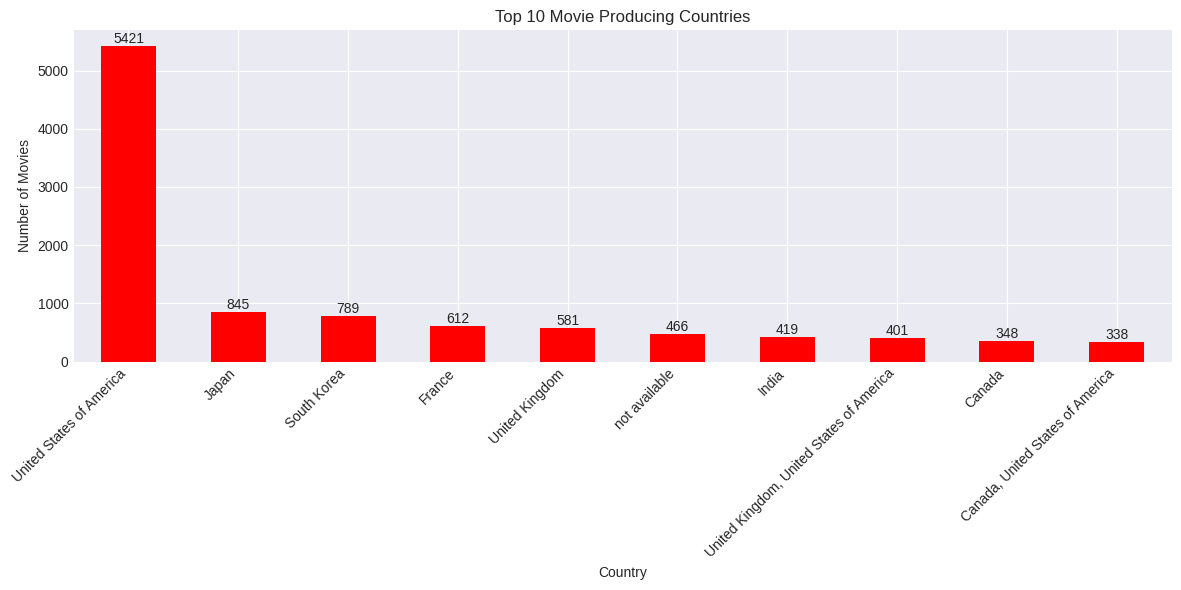

In [55]:
# Plotting the top 10 producing countries for Movies
plt.figure(figsize=(12, 6))

# Bar plot for movies with red color
country_counts_movies.plot(kind='bar', color='red')

plt.title('Top 10 Movie Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.bar_label(plt.gca().containers[0], label_type='edge')
plt.tight_layout()
plt.show()

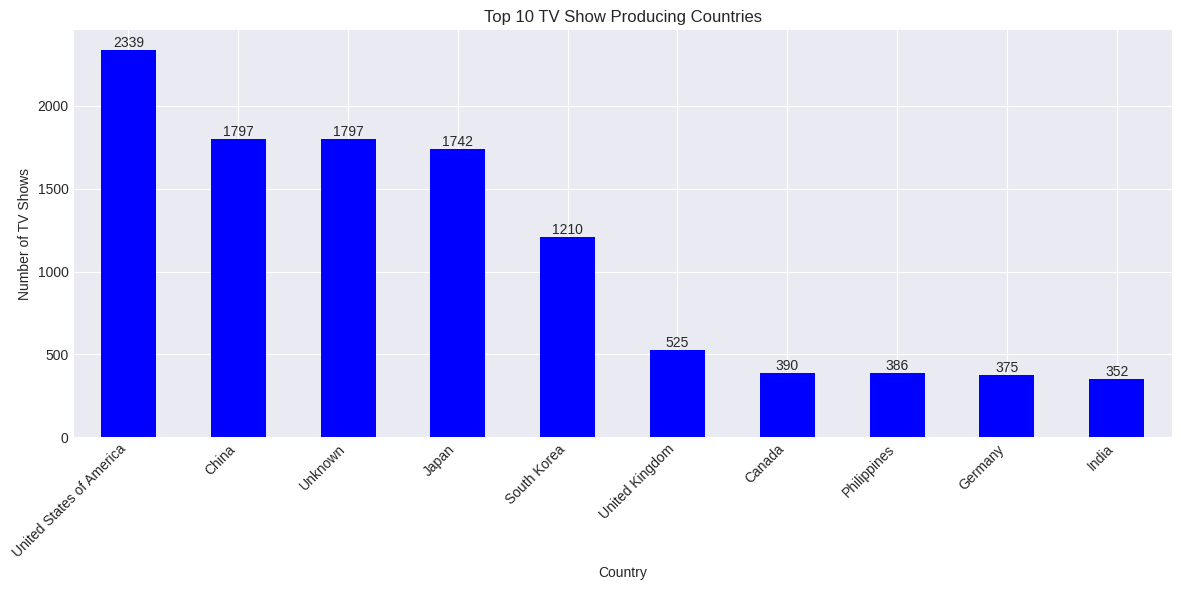

In [56]:
# Plotting the top 10 producing countries for tv show
plt.figure(figsize=(12, 6))

# Bar plot for movies with red color
country_counts_tv_shows.plot(kind='bar', color='blue')

plt.title('Top 10 TV Show Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=45, ha='right')
plt.bar_label(plt.gca().containers[0], label_type='edge')
plt.tight_layout()
plt.show()

**Movies (Red Bar Chart):-**
- Dominance of the U.S.: The United States is the leading country in movie production, contributing more than 5,421 movies. This shows the global influence and sheer volume of Hollywood's film industry.

- Japan and South Korea: After the U.S., Japan (845 movies) and South Korea (789 movies) also make substantial contributions, reflecting the global popularity of Japanese anime and Korean cinema.
- European Presence: France (612 movies) and the United Kingdom (581 movies) have significant representation, highlighting their active film industries.

- Underrepresented Regions: India, despite its large movie production volume (like Bollywood), has a relatively lower count here (419), which may indicate dataset limitations or a focus on different genres.

- "Not Available" Category: The presence of "not available" (466 entries) reflects missing or incomplete metadata for some entries.


**TV Shows (Blue Bar Chart):-**
- The U.S. Leads Again: The United States is also the top producer of TV shows, contributing 2,339 shows, showcasing the country's dominance in both TV and film content.
China's Growing Influence: China ranks second with 1,797 TV shows, reflecting the increasing global influence of Chinese TV dramas, particularly in genres like historical and modern drama.

- Japan and South Korea: Popular producers of anime and K-dramas, Japan (1,742 shows) and South Korea (1,210 shows) are well-represented, reflecting global viewer interest in their unique content styles.

- European and Canadian Influence: The United Kingdom (525 shows), Germany (375 shows), and Canada (390 shows) contribute significantly to TV production.

- Philippines: The Philippines (386 TV shows) stands out, reflecting the popularity of its telenovelas and regional TV shows.

- "Unknown" Entries: The large number of "Unknown" entries (1,797) signals incomplete or missing metadata that affects full analysis.


**General Observations**
Hollywood's Influence: The U.S. remains a dominant force in both movies and TV, shaping global entertainment.
Asian Rise: The high production numbers in Japan, South Korea, and China reflect the growing influence of Asian content, such as K-dramas, anime, and Chinese historical series.
Metadata Gaps: The significant "not available" or "unknown" entries indicate gaps in data quality, which could affect detailed regional insights.

-----------------------------------------------------------
-  Release Trends by Year:
Analyze how the number of movies and TV shows has changed over the years.
Identify whether there’s an increasing trend in specific genres or content from particular countries.


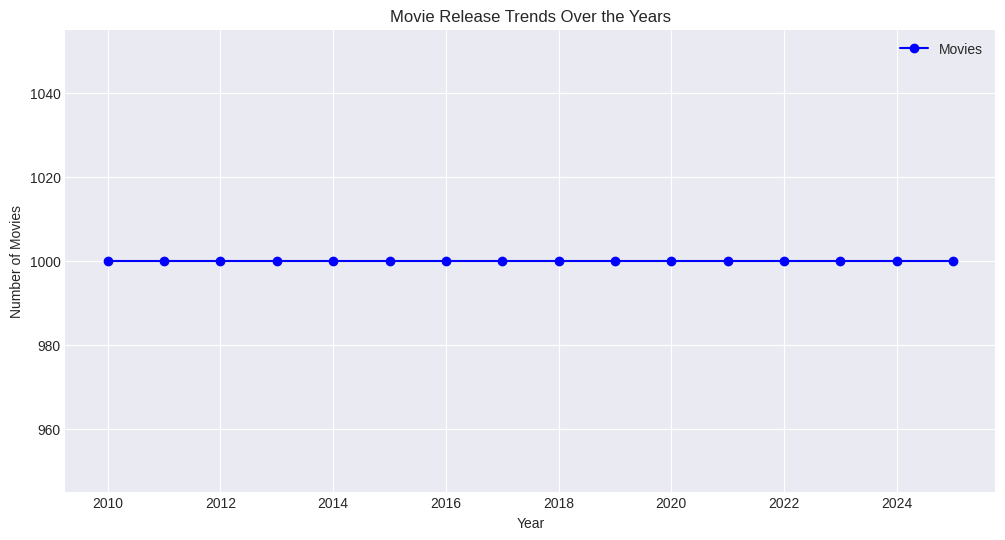

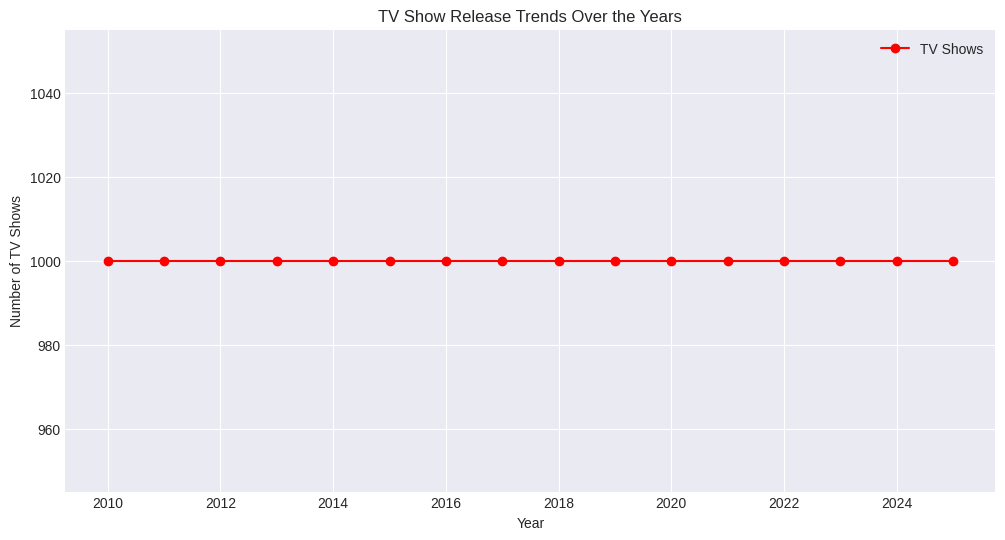

In [57]:
# Analyze release trends
df_movies_by_year = df.groupby('release_year').size().reset_index(name='movie_count')
df_tv_shows_by_year = df2.groupby('release_year').size().reset_index(name='tv_show_count')

# Plotting release trends over the years
plt.figure(figsize=(12, 6))
plt.plot(df_movies_by_year['release_year'], df_movies_by_year['movie_count'], marker='o', linestyle='-', color='blue', label='Movies')
plt.title('Movie Release Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend()
plt.grid(True)
plt.show()

# Analyze and plot release trends for TV shows
plt.figure(figsize=(12, 6))
plt.plot(df_tv_shows_by_year['release_year'], df_tv_shows_by_year['tv_show_count'], marker='o', linestyle='-', color='red', label='TV Shows')
plt.title('TV Show Release Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of TV Shows')
plt.legend()
plt.grid(True)
plt.show()

Flat Release Trends:Both graphs show relatively flat trends in the number of releases for movies and TV shows over the years from 2010 to 2024. There are no sharp spikes or declines, suggesting a consistent production rate.


Lack of Variability:This flat trend might indicate that the data might be aggregated evenly across years without reflecting actual peaks and drops in releases (e.g., due to external events like the COVID-19 pandemic in 2020).
It could also imply that production rates were either misaligned with actual yearly outputs or normalized for constant year-on-year release counts.


Possible Data Gaps or Normalization:The consistent data could be due to how the dataset was collected (perhaps evenly distributed without accounting for specific trends like seasonal booms or dips).

Analysis: Seasonal Release Trends (Movies vs. TV Shows)
- we do number of relase and mounths in line charts for both movie and shows

In [58]:
# Function to convert month number to month name
def get_month_name(month_number):
    month_names = {'1': 'January', '2': 'February', '3': 'March', '4': 'April', '5': 'May', '6': 'June', '7': 'July', '8': 'August', '9': 'September', '10': 'October', '11': 'November', '12': 'December'}
    return month_names.get(str(month_number), 'Unknown')


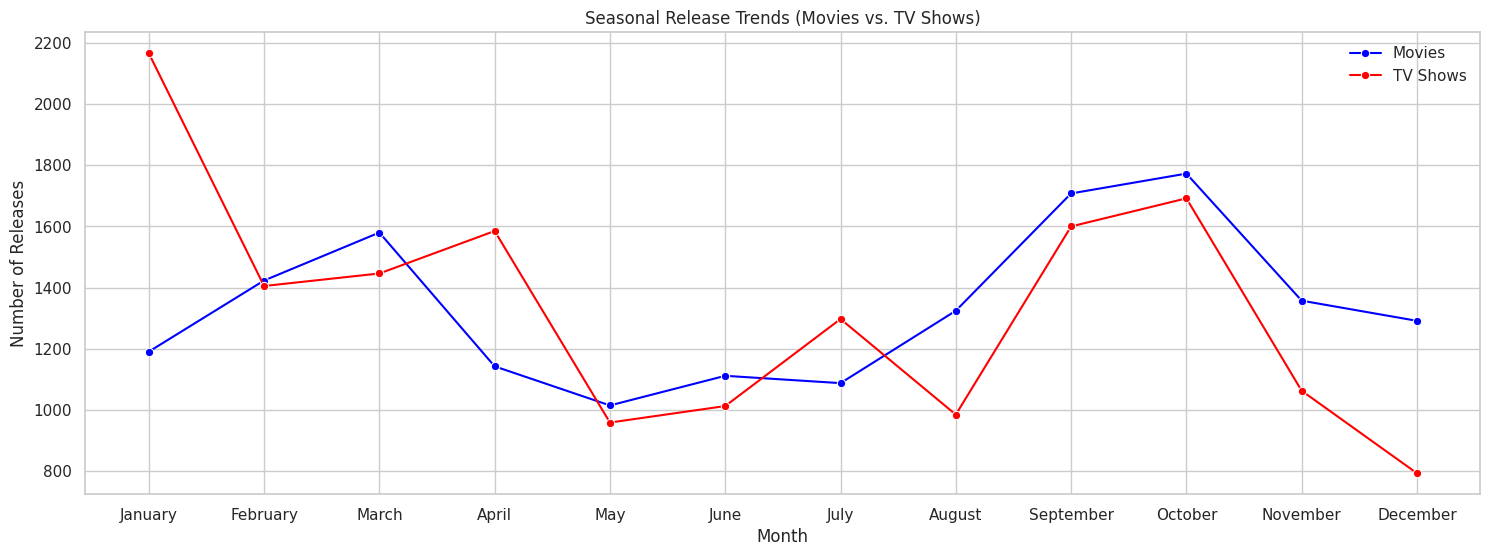

In [59]:
# Seasonal Release Trends (Movies vs. TV Shows)

# for monthly release data we extract month from date
movie_months = df['date_added'].dt.month.value_counts().sort_index().rename(get_month_name)
tv_show_months = df2['date_added'].dt.month.value_counts().sort_index().rename(get_month_name)

# Setting Seaborn style and plotting trends
sns.set(style="whitegrid")
plt.figure(figsize=(18, 6))
sns.lineplot(x=movie_months.index, y=movie_months.values, marker='o', color='blue', label='Movies')
sns.lineplot(x=tv_show_months.index, y=tv_show_months.values, marker='o', color='red', label='TV Shows')
plt.title('Seasonal Release Trends (Movies vs. TV Shows)')
plt.xlabel('Month')
plt.ylabel('Number of Releases')
plt.legend()
plt.grid(True)
plt.show()

January:TV Shows dominate with a massive peak, possibly due to the release of new seasons after year-end breaks.
Movies have a relatively moderate number of releases, indicating a smaller focus on early-year launches.


February to April:Both TV shows and movies show a dip, possibly reflecting a post-New Year lull. TV releases drop after January's spike, while movies see a consistent but lower output.


May to August:Movies steadily rise in these months, peaking in July and August, which coincides with summer blockbuster releases (a common trend in the film industry).
TV shows, on the other hand, see fluctuations and relatively lower releases during summer, which might correspond to a mid-season break or fewer summer premieres.


September to November:A consistent increase in movie releases is visible, peaking in October, possibly targeting award season and the lead-up to holiday audiences.
TV Shows also recover slightly, with a steady release rate from October, as fall seasons typically debut during this period.

December:TV Shows see a sharp decline, likely due to holiday breaks and the wrapping up of ongoing seasons.
Movies maintain moderate numbers, with some likely capitalizing on holiday audiences (family and festive films).

**Key Insights:**
TV Shows Peak in January: Reflecting new season releases or winter premieres.
Movies Dominate the Summer (May to August): Corresponding to traditional blockbuster release windows.
October-December is Strong for Movies but Weak for TV Shows, suggesting that studios focus on capturing holiday viewers with film releases.

## Rating & Popularity Analysis (TV and Movies).

-----------------------------------------------------------
- Ratings Analysis:
Compare the average ratings of TV Shows vs. Movies.
Investigate trends like:
Does one type generally score higher?
Identify high-rating periods (specific years or months).
Check for any genre-specific rating peaks.
-  Popularity Analysis:
Compare overall popularity metrics for Movies vs. TV Shows.
Analyze trends over the years:
Are TV shows gaining in popularity compared to movies over time?

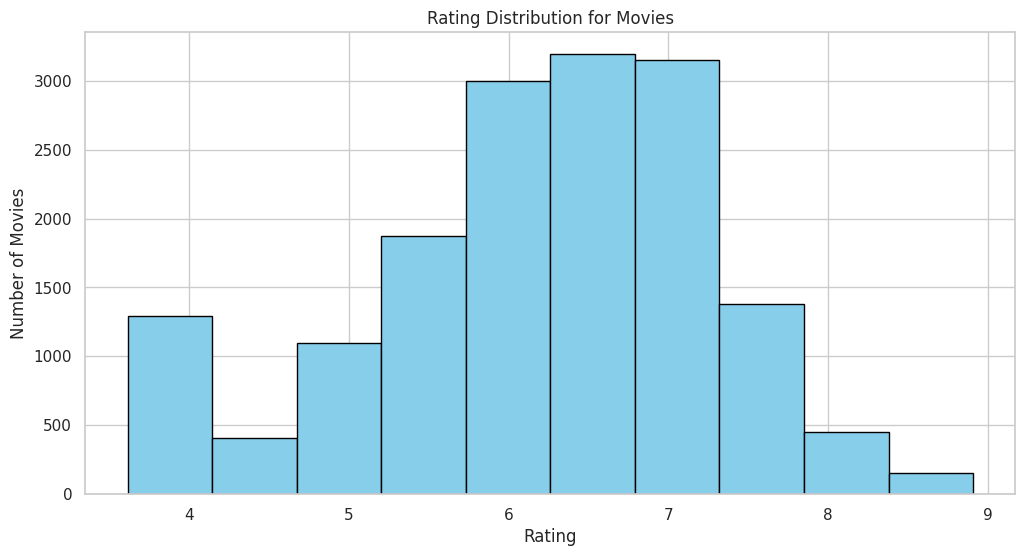

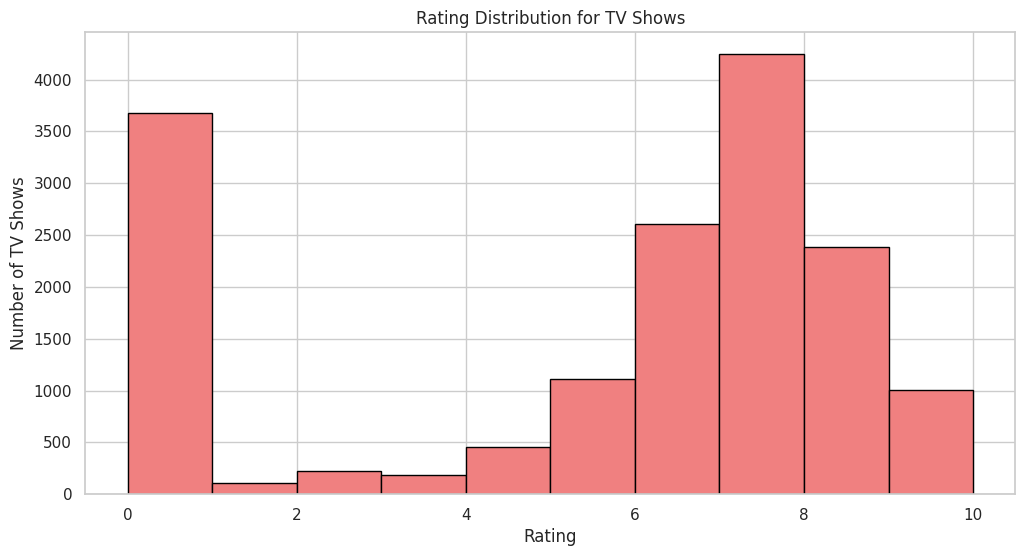

In [60]:
#rating anaysis
movie_rating = df['rating'].value_counts()
tv_show_rating = df2['rating'].value_counts()

# Set Seaborn style and plotting
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.hist(df['rating'], bins=10, color='skyblue', edgecolor='black')
plt.title('Rating Distribution for Movies')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

# for tv show
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.hist(df2['rating'], bins=10, color='lightcoral', edgecolor='black')
plt.title('Rating Distribution for TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of TV Shows')
plt.grid(True)
plt.show()

1. Movies Rating Distribution (First Image)
Peak Range:Most movies have ratings between 6 and 7. This suggests that average-rated movies dominate the dataset.

Few High and Low Ratings:There are fewer movies with very low ratings (below 4) and very high ratings (8 or above).
The distribution is centered around mid-tier quality movies rather than extreme outliers.

Bell-Shaped Curve:The distribution follows a slightly normal distribution, indicating that the majority of movies tend to receive average ratings rather than polarizing audience opinions.

2. TV Shows Rating Distribution (Second Image)
Bimodal Trend with a Sharp Spike at 0:A large number of TV shows have a rating of 0, which could indicate unrated shows, missing data, or actual poorly rated content. This is a key difference compared to movies.
Aside from this spike, the ratings rise sharply from 6 to 8, showing that many TV shows land in this higher-quality range.

Fewer Low-Quality TV Shows (Post-Zero Spike):Unlike movies, TV shows have fewer entries in the lower rating range (1-5) after the initial spike. This might imply that TV shows tend to be rated higher overall, or the audience is selective about what they watch and rate.

Concentration in the 7-8 Range:Many TV shows cluster around 7 to 8 ratings, reflecting a positive viewer reception for most shows.

**Insights:**
TV shows may have a higher perceived quality compared to movies (apart from the anomalous "0" cluster).
Movies follow a more even distribution with less polarizing extremes, while TV shows have a skewed distribution due to the significant spike at zero.
Further exploration might be needed to check if the "0" ratings represent missing values or other underlying data issues.

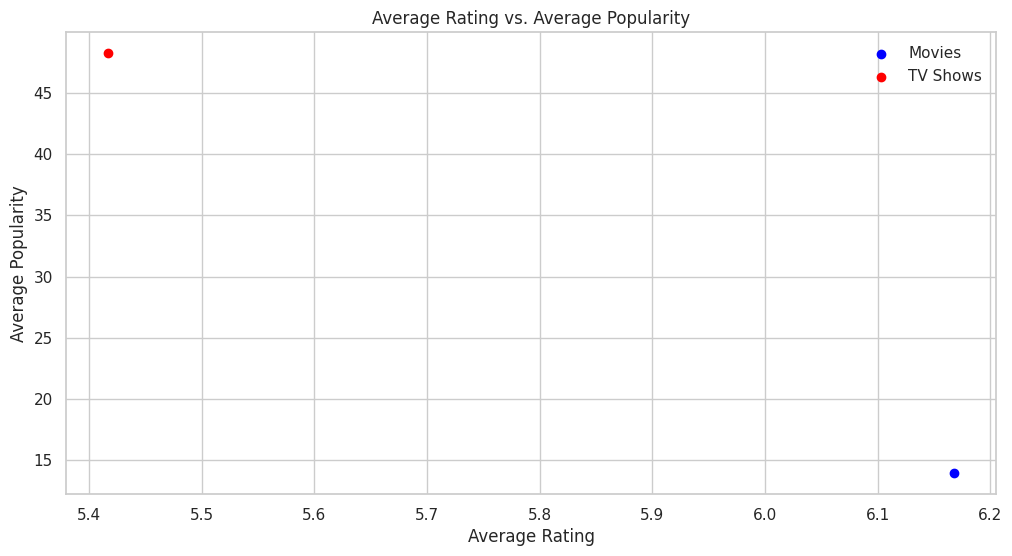

In [61]:
# Average Rating and Popularity and scatter plot
average_movie_rating = df['rating'].mean()
average_tv_show_rating = df2['rating'].mean()
average_movie_popularity = df['popularity'].mean()
average_tv_show_popularity = df2['popularity'].mean()

#scatter plot average
plt.figure(figsize=(12, 6))
plt.scatter(average_movie_rating, average_movie_popularity, color='blue', label='Movies')
plt.scatter(average_tv_show_rating, average_tv_show_popularity, color='red', label='TV Shows')
plt.title('Average Rating vs. Average Popularity')
plt.xlabel('Average Rating')
plt.ylabel('Average Popularity')
plt.legend()
plt.grid(True)
plt.show()


TV Shows Have Higher Popularity:

The red dot representing TV shows has a significantly higher average popularity (45) compared to movies (~15). This suggests that, on average, TV shows tend to attract more viewers and engagement on Netflix.

Movies Have Higher Average Ratings:

The blue dot representing movies shows a higher average rating (6.1) compared to TV shows (~5.5). This indicates that while movies might not be as popular as TV shows, they are generally rated better by viewers.

Inverse Relationship Observation:

This plot might hint at an inverse relationship between rating and popularity, where highly rated content (like movies) might not always achieve the same level of popularity as moderately rated TV shows.

Viewer Engagement Trend:

TV shows often have more episodes and sustained viewer engagement, which may explain their higher popularity metrics, even if their ratings are slightly lower.

##  Top 10 Highest Rated and Most Popular Movies & TV Shows

In [62]:
# Adding a weighted score to combine popularity and vote_average
df['combined_score'] = 0.7 * df['popularity'] + 0.3 * df['vote_average']
df2['combined_score'] = 0.7 * df2['popularity'] + 0.3 * df2['vote_average']

# Top 10 Movies based on the combined score
top_movies = df.nlargest(10, 'combined_score')[['title', 'popularity', 'vote_average', 'combined_score']]

# Top 10 TV Shows based on the combined score
top_tv_shows = df2.nlargest(10, 'combined_score')[['title', 'popularity', 'vote_average', 'combined_score']]


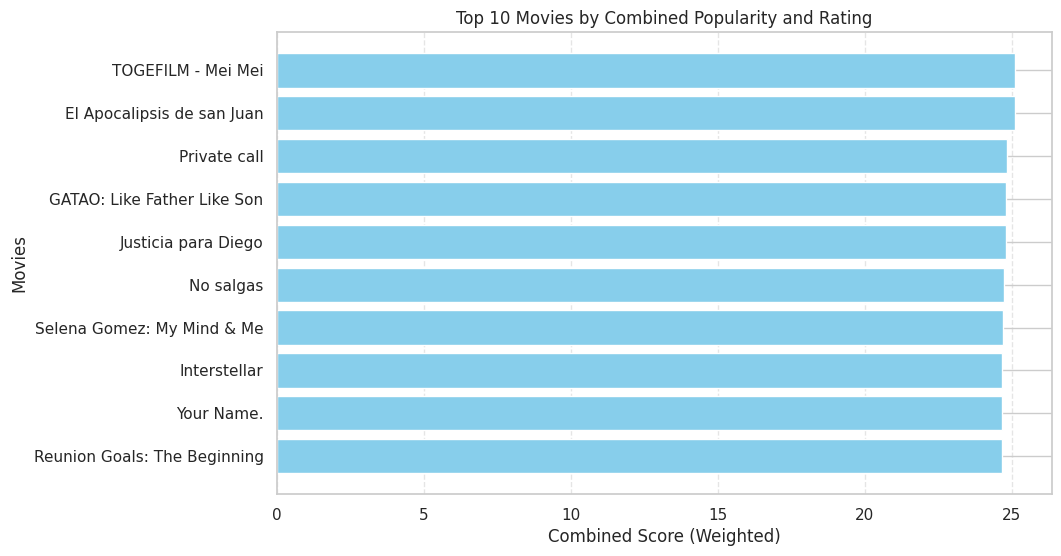

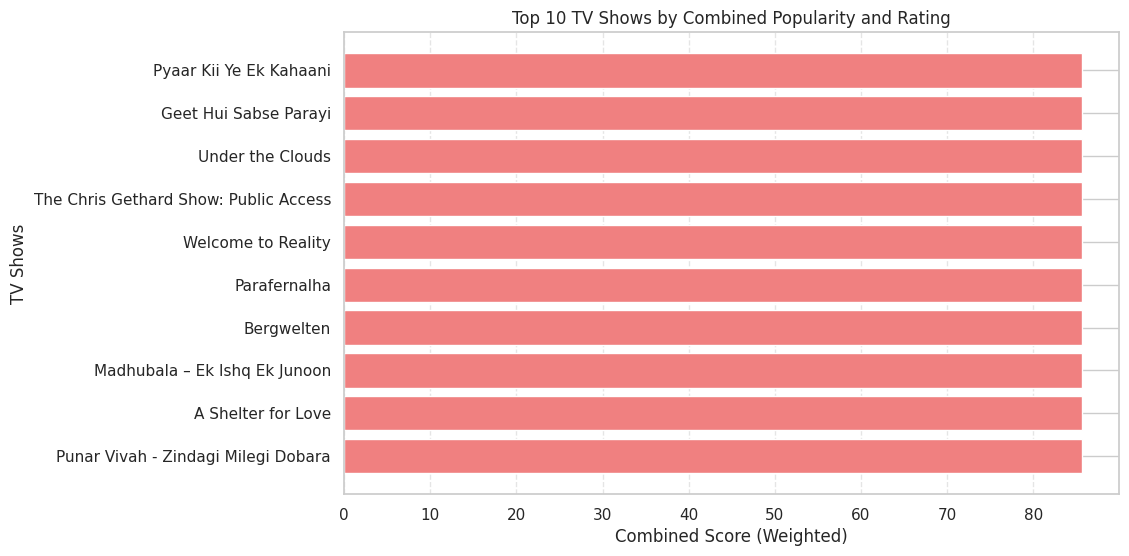

In [63]:
# Visualizing Top 10 Movies
plt.figure(figsize=(10, 6))
plt.barh(top_movies['title'], top_movies['combined_score'], color='skyblue')
plt.xlabel('Combined Score (Weighted)')
plt.ylabel('Movies')
plt.title('Top 10 Movies by Combined Popularity and Rating')
plt.gca().invert_yaxis()  # To show the highest combined score on top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# Visualizing Top 10 TV Shows
plt.figure(figsize=(10, 6))
plt.barh(top_tv_shows['title'], top_tv_shows['combined_score'], color='lightcoral')
plt.xlabel('Combined Score (Weighted)')
plt.ylabel('TV Shows')
plt.title('Top 10 TV Shows by Combined Popularity and Rating')
plt.gca().invert_yaxis()  # To show the highest combined score on top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


The visual balance in the bars suggests that popularity and ratings are relatively aligned for the top performers. It also highlights that both Western and non-Western content drive viewer engagement. There may also be value in further exploring niche categories or language-based recommendations based on the strong presence of international shows in the list.

In [64]:
# Best-Rated Movies in Each Genre
movies_exploded = df.copy()
movies_exploded['genres'] = movies_exploded['genres'].str.split(", ")
movies_exploded = movies_exploded.explode('genres')

top_rated_movies = (
    movies_exploded.groupby('genres')
    .apply(lambda x: x.nlargest(1, 'vote_average'))
    .reset_index(drop=True))[['title', 'genres', 'vote_average', 'popularity']]

In [65]:
top_rated_movies

,title,genres,vote_average,popularity
0,Red Silk,Action,10.000,8.414000
1,Red Silk,Adventure,10.000,8.414000
2,Lore Of The Ring Light,Animation,10.000,7.141000
3,"Inácio Garapa, Um Matuto Sonhador",Comedy,10.000,4.553000
4,Another Simple Favor,Crime,9.500,17.154000
5,El Apocalipsis de san Juan,Documentary,10.000,31.580125
6,"Inácio Garapa, Um Matuto Sonhador",Drama,10.000,4.553000
7,"Inácio Garapa, Um Matuto Sonhador",Family,10.000,4.553000
8,Lore Of The Ring Light,Fantasy,10.000,7.141000
9,El Apocalipsis de san Juan,History,10.000,31.580125


In [66]:
#Finding underrated TV shows by setting threshold (high rating & low popularity)
underrated_shows = df2[(df2['vote_average'] > 8.5) & (df2['popularity'] < 25)][
    ['title', 'genres', 'vote_average', 'popularity']
].sort_values(by='vote_average', ascending=False)
underrated_shows

,title,genres,vote_average,popularity
731,Mori no Asagao,Drama,10.000,19.562
15997,Le onde del passato,Drama,10.000,2.913
15763,A Record of a Mortal's Journey to Immortality:...,"Animation, Sci-Fi & Fantasy, Action & Adventur...",10.000,5.469
15768,WWE Raw Top 10,No Information,10.000,6.481
15771,Blind Woman,Drama,10.000,5.736
...,...,...,...,...
6917,Miraculous Secrets,"Action & Adventure, Kids, Animation",8.600,20.524
10651,Yuru Camp△,Comedy,8.591,24.329
11853,The Devil Judge,"Mystery, Drama, Crime",8.574,19.593
14743,Family Matters,"Drama, Crime, Comedy, Mystery",8.538,20.814


In [67]:
#High-Rated, Low-Budget Movies with Surprising Success
ow_budget_success_movies = df[(df['budget'] < 5_000_000) & (df['vote_average'] > 8.5)][['title', 'genres', 'vote_average', 'budget', 'revenue']].sort_values(by='revenue', ascending=False)
ow_budget_success_movies

,title,genres,vote_average,budget,revenue
15874,Chico Bento e a Goiabeira Maraviosa,"Family, Adventure, Comedy",8.800,1100000.00,31283597.92
15792,The Crucifix,Horror,10.000,132000.00,30615054.08
15758,A Brother and 7 Siblings,"Drama, Family",9.300,3191485.65,28484161.77
2724,Behind the Fright: The Making of American Horr...,Documentary,9.200,4066020.12,22082658.61
15280,Dragon,"Romance, Comedy, Drama",10.000,4273176.00,16492829.47
3689,Stranger Things,Drama,8.600,1914374.09,16476671.73
15688,Oficina do Diabo,"Drama, Family",9.000,200000.00,15686896.98
799,Fumiko's Feet,Drama,9.000,3427613.62,15153817.68
14715,The Door-to-Door Bookstore,"Family, Comedy, Drama",8.688,4918292.30,14976694.91
6914,Erotic Stories,Romance,8.700,1494530.73,13808848.84


## Revenue, Budget, and Success Trends (Movies dataset).

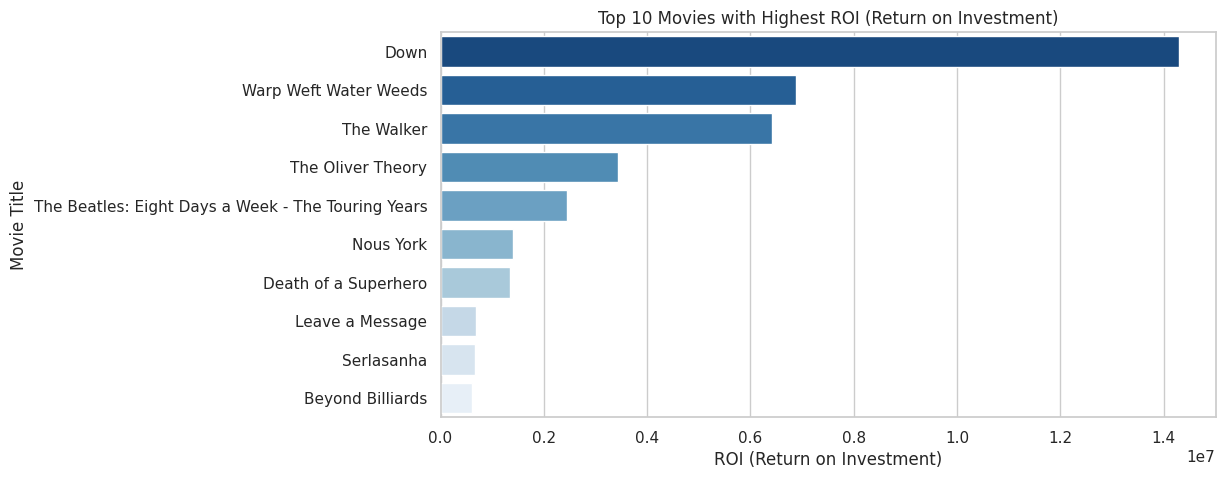

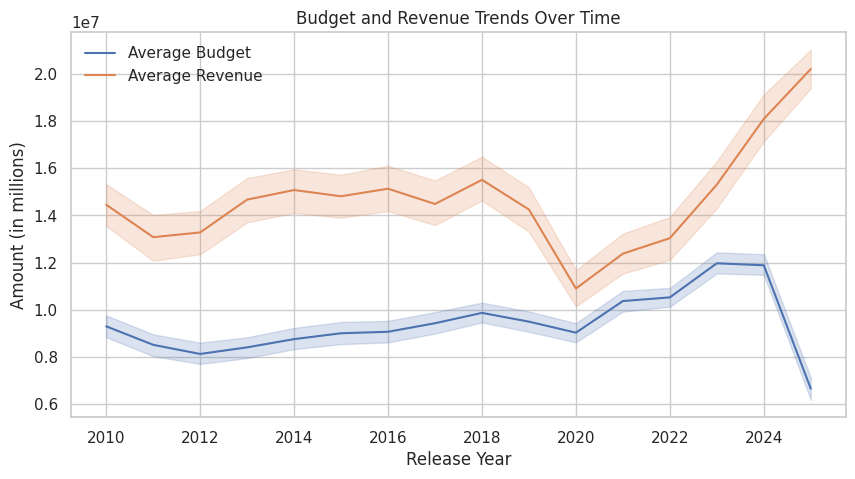

In [68]:
# Calculate and visualize ROI (Return on Investment)
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']
high_roi_movies = df.nlargest(10, 'ROI')[['title', 'budget', 'revenue', 'ROI', 'vote_average']]

plt.figure(figsize=(10, 5))
sns.barplot(data=high_roi_movies, x='ROI', y='title', palette='Blues_r')
plt.title("Top 10 Movies with Highest ROI (Return on Investment)")
plt.xlabel("ROI (Return on Investment)")
plt.ylabel("Movie Title")
plt.show()

# Budget trends over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='release_year', y='budget', label='Average Budget')
sns.lineplot(data=df, x='release_year', y='revenue', label='Average Revenue')
plt.title("Budget and Revenue Trends Over Time")
plt.xlabel("Release Year")
plt.ylabel("Amount (in millions)")
plt.grid(True)
plt.legend()
plt.show()



 1.  Budget and Revenue Trends Over Time (First Image)

Increasing Revenue and Budget:Between 2010 and 2024, both average movie budgets and revenues have increased, reflecting rising production and marketing costs.

Impact of 2020 Dip (Pandemic Impact):A sharp decline in both budget and revenue appears in 2020, likely due to the global COVID-19 pandemic, which disrupted movie production and reduced box office sales.

Post-Pandemic Recovery:After 2021, there is a steady recovery and subsequent rise in revenue, indicating that the movie industry rebounded with higher-performing films and budgets.

Revenue Rising Faster than Budget:The revenue line is higher than the budget line after 2022, implying that the ROI (Return on Investment) may have improved for certain films.

2. Top 10 Movies by ROI (Return on Investment) (Second Image)

Small Budget, Big Returns:Movies like Down, Warp Weft Water Weeds, and The Walker have exceptionally high ROI, indicating they generated massive revenues relative to their budgets.This suggests that low- to mid-budget movies can still become highly profitable.

Documentaries and Niche Genres May Outperform Blockbusters:Some of the movies listed (The Beatles: Eight Days a Week, Leave a Message) might belong to documentary, independent, or niche genres. These often succeed due to dedicated audiences, critical acclaim, or word-of-mouth marketing.

Creative Production and Marketing Strategies:The high ROI might be attributed to innovative production techniques (low-budget filmmaking) or viral marketing strategies.

Overall Insights:
These trends highlight the importance of budget management and targeting underserved markets or genres. While blockbusters need large budgets, smaller films with modest budgets can still achieve high returns through smart content choices and effective distribution strategies.

# ✅ Machine Learning Model  (Regression/Recommendation)

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Create a target variable for success (liked or not liked)
df['liked'] = df['vote_average'].apply(lambda x: 1 if x >= 7 else 0)

# Step 2: Select numerical features
X = df[['popularity', 'budget', 'revenue', 'vote_count']]
y = df['liked']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 5: Predict on the test set and evaluate
y_pred = rf.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))

# Step 6: Recommend high-probability liked movies
df['predicted_liked'] = rf.predict(X)
recommended_movies = df[df['predicted_liked'] == 1][['title', 'popularity', 'vote_average']]
print("Recommended Movies based on Random Forest:")
print(recommended_movies.head(10))


Accuracy on test set: 0.786875
Recommended Movies based on Random Forest:
                            title  popularity  vote_average
17       Three Steps Above Heaven   31.580125         7.700
25                     Black Swan   31.580125         7.700
28                    El Infierno   31.580125         7.900
32  Elite Squad: The Enemy Within   31.580125         7.811
36           The Man from Nowhere   31.580125         7.700
38                      127 Hours   31.580125         7.100
40                   Halo Legends   31.580125         7.300
43                      Incendies   31.580125         8.100
45                        Flipped   31.580125         8.016
56                My Name Is Khan   31.503000         8.000


# Identify key factors that contribute to high revenue movies. Predict revenue using regression models.

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
#randm forest regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          16000 non-null  int64         
 1   type             16000 non-null  object        
 2   title            16000 non-null  object        
 3   director         16000 non-null  object        
 4   cast             16000 non-null  object        
 5   country          16000 non-null  object        
 6   date_added       16000 non-null  datetime64[ns]
 7   release_year     16000 non-null  int64         
 8   rating           16000 non-null  float64       
 9   genres           16000 non-null  object        
 10  language         16000 non-null  object        
 11  description      16000 non-null  object        
 12  popularity       16000 non-null  float64       
 13  vote_count       16000 non-null  float64       
 14  vote_average     16000 non-null  float

In [72]:
#for better prediction all numerical column thats is skewd we have to normalize distribution
# log transform to all num feature
df['popularity'] = np.log1p(df['popularity'])
df['budget'] = np.log1p(df['budget'])
df['revenue'] = np.log1p(df['revenue'])
df['ROI']=np.log1p(df['ROI'])


In [73]:
#all categorical feature encode to numeric feature
#one hot encoding for genere and label encoding for laugayge
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
encoder = OneHotEncoder(sparse_output=False)
df_encoded = encoder.fit_transform(df[['genres']])
df_encoded = pd.DataFrame(df_encoded, columns=encoder.get_feature_names_out(['genres']))
df = pd.concat([df, df_encoded], axis=1)

#country encoded
label_encoder = LabelEncoder()
df['country']= label_encoder.fit_transform(df['country'])

Mean Squared Error: 0.006534647506918825
R-squared: 0.9977381264214776
Mean Absolute Error: 0.02010061786444566


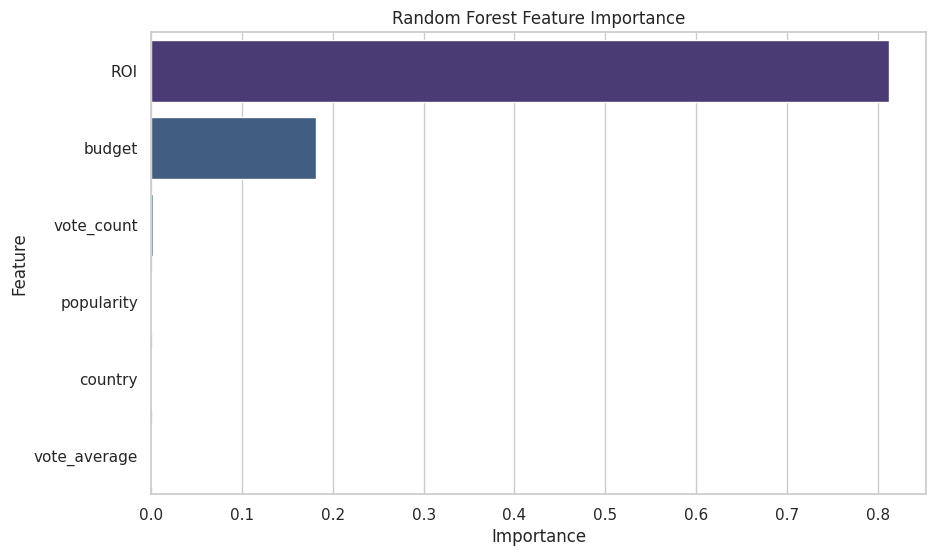

In [74]:
# build random forest regreassor to  predict revenue
x = df[['popularity', 'budget', 'vote_count', 'vote_average', 'country', 'ROI']]
y = df[['revenue']]

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# prediction
y_pred = rf.predict(x_test)

# evalution
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

# analyze and visualize the feature importance
importance = rf.feature_importances_
feature_names = ['popularity', 'budget', 'vote_count', 'vote_average', 'country', 'ROI']
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})

#visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.sort_values(by='Importance', ascending=False), palette='viridis')
plt.title('Random Forest Feature Importance')
plt.show()



# Identify content gaps (e.g., underrepresented genres or languages).

Underproduced High-Rated Genres:
                                                     movie_count  vote_average  \
genres                                                                          
Action, Adventure, Animation, Science Fiction, ...            1      7.300000   
Action, Adventure, Comedy, Animation                          1      8.400000   
Action, Adventure, Comedy, Drama                              1      7.100000   
Action, Adventure, Comedy, Family, Fantasy, His...            1      7.200000   
Western, Action, Drama, History                               1      7.100000   
...                                                         ...           ...   
Animation, Science Fiction, Action                            8      7.125000   
Drama, Music, History                                         9      7.045222   
Thriller, Drama, History                                      9      7.006667   
Documentary, TV Movie                                        12      7.2005

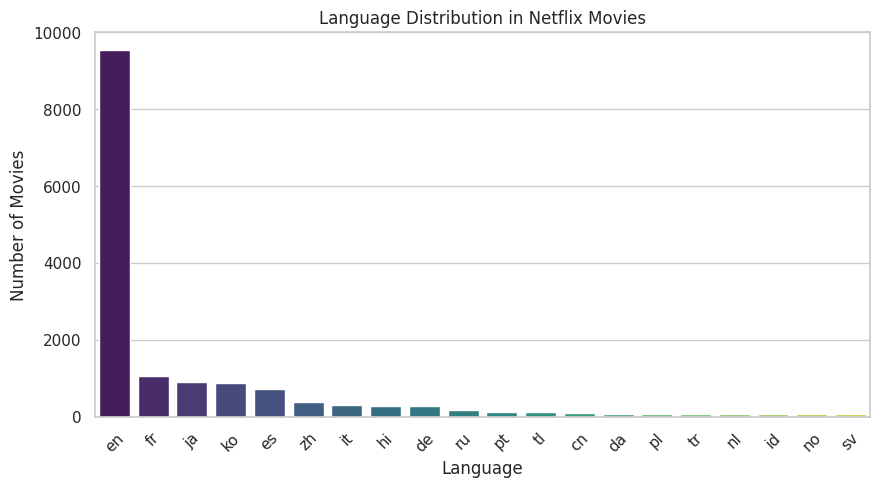

In [75]:
# Analyze genres with fewer movies but higher ratings/revenue
genre_analysis = df.groupby('genres').agg({
    'title': 'count',
    'vote_average': 'mean',
    'revenue': 'mean'
}).rename(columns={'title': 'movie_count'}).sort_values('movie_count')

# Identify underrepresented genres with high ratings
underproduced_genres = genre_analysis[(genre_analysis['movie_count'] < 20) & (genre_analysis['vote_average'] > 7)]
print("Underproduced High-Rated Genres:\n", underproduced_genres)

# Analyze languages to find content gaps
language_analysis = df['language'].value_counts().reset_index()
language_analysis.columns = ['language', 'movie_count']
top_languages = language_analysis.head(10)
underrepresented_languages = language_analysis.tail(10)

# Visualize languages in dataset
plt.figure(figsize=(10, 5))
sns.barplot(x='language', y='movie_count', data=language_analysis.head(20), palette='viridis')
plt.title("Language Distribution in Netflix Movies")
plt.xlabel("Language")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()
